<div align="center">
  <b><br>
  <b><br>
  <b><font color="white" size="8">PROCESAMIENTO DE DATOS DEL GOES-19 CON PYTHON</font><br>
  <b><br>
  <b><font color="white" size="5">Joao Huamán</font><br>
  <b><br>
  <b><font color="white" size="4">18 de marzo de 2026</font><br>
  <b><br>
</div>

La parte practica del curso será trabajado en **Colab**. <br>

**¿Que es Colab?** <br>
Google Colab (Colaboratory) es una plataforma gratuita de Google que permite escribir y ejecutar código Python en la nube mediante notebooks, sin necesidad de instalar nada localmente. Está basada en Jupyter Notebooks, pero con integración en la nube, almacenamiento temporal, y acceso a recursos como CPUs y GPUs.
Cada notebook de Colab se ejecuta en un entorno temporal que incluye un sistema de archivos montado en la ruta /content/. Todo lo que se almacene en esta ubicación se perderá una vez que el entorno se cierre o se reinicie.
Cada entorno de ejecución simula un servidor linux en el que se encuentran preinstaladas varios paquetes de Python.

Los paquetes que utilizaremos en el curso son los siguientes:
- [Numpy](https://numpy.org/doc/stable/index.html)
- [Matplotlib](https://matplotlib.org/stable/)
- [Cartopy](https://scitools.org.uk/cartopy/docs/latest/)
- [NetCDF4](https://unidata.github.io/netcdf4-python/)
- [GOES](https://github.com/joaohenry23/GOES)

Algunos de ellos, como Numpy y Matplotlib, ya se encuentran preinstalados. Los paquetes faltantes pueden ser instalados de la siguiente forma:

In [1]:
!pip install cartopy
!pip install netCDF4
!pip install GOES

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 88.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.2.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is i

Para verificar que se han instalado correctamente, debemos importalos. Si no obtenemos ningún mensaje, entonces la instalación fue exitosa.

In [2]:
import GOES                 # importamos la libreria
import netCDF4 as nc        # importamos la libreria con un alias
import cartopy.crs as ccrs  # importamos parte de la libreria con un alias

# **Tipos de datos de python**

## Datos básicos
Los que vienen integrados con python, como:
- integer (int): números enteros. Ej: ```42, 7, 1000```
- float (float): números decimales. Ej: ```3.14, -1.5```
- string (str): cadenas de texto. Ej: ```"hola", "Perú"```
- boolean (bool): valores loógicos. Ej: ```True, False```

## Datos compuestos:
Son contenendores de multiples datos básicos:


- tuple (tuple): secuencia de elementos cuyo valor **no pueden cambiar su valor**.

In [3]:
l = (2, 3)
print(l)
m = ('a','b')
print(m)

(2, 3)
('a', 'b')


- list (list): secuencia de elementos que **sí pueden cambiar su valor**, pero que no puede realizar operaciones matemáticas vectorizadas.

In [4]:
l = [1,2,3]
print(l)
m = ["a","b","c"]
print(m)
n = [13, 5.7, "hola mundo", True]
print(n)

[1, 2, 3]
['a', 'b', 'c']
[13, 5.7, 'hola mundo', True]


In [5]:
l = [1,2,3,50]

In [6]:
l[0] = 100
print(l)

[100, 2, 3, 50]


- dictionary (dict): secuencia de elementos cuya estructura se base en pares **key** - **value**. <br>

In [7]:
l = {'frutas': ['naranja'], 'precio': [2.5, 3.0, 4], 'info':'esto es un ejemplo'}
print(l)
m = {'nombre': ['José', 'Pedro', 'Miguel'], 'edad': [10, 11, 10]}
print(m)

{'frutas': ['naranja'], 'precio': [2.5, 3.0, 4], 'info': 'esto es un ejemplo'}
{'nombre': ['José', 'Pedro', 'Miguel'], 'edad': [10, 11, 10]}


- array (array): secuencia de elementos multidimensional que **sí** puede realizar operaciones matemáticas vectorizadas. Es creado por el paquete **Numpy**, por lo cual debe importarse esta libreria para poder crear este tipo de contenedor.

In [8]:
import numpy as np

In [9]:
values = [4,2,5,10]
a1 = np.array(values)
print(a1)

[ 4  2  5 10]


In [10]:
a2 = np.array([4,2,5,10])
print(a2)

[ 4  2  5 10]


In [11]:
m = np.array([[4, 20.1, 3.0, 10],[1, 0.5, 2.0, 4.0]])
print(m)

[[ 4.  20.1  3.  10. ]
 [ 1.   0.5  2.   4. ]]


In [12]:
n = np.array([[[4, 20.1, 3.0, 10],[1, 0.5, 2.0, 4.0]],[[0,8,5,6],[1.1,4.2,3.4,0.5]]])
print(n)

[[[ 4.  20.1  3.  10. ]
  [ 1.   0.5  2.   4. ]]

 [[ 0.   8.   5.   6. ]
  [ 1.1  4.2  3.4  0.5]]]


In [13]:
print(n.ndim) # numero de dimensiones del array

3


In [14]:
print(n.shape) # forma del array

(2, 2, 4)


In [15]:
n = n + 10
print(n)

[[[14.  30.1 13.  20. ]
  [11.  10.5 12.  14. ]]

 [[10.  18.  15.  16. ]
  [11.1 14.2 13.4 10.5]]]


Realicemos operaciones:

In [16]:
m = (200,300,400)
n = np.array([200,300,400])

In [17]:
n / 100

array([2., 3., 4.])

**Importante:**
- la posicion de los elementos de un array comienzan en 0
<pre>
  Ejemplo:
  m = [8,23,19,10]
  m[0]  -->  8
  m[1]  -->  23
  m[2]  -->  19
  m[3]  -->  10
  m[-1] -->  10
</pre>

- las dimensiones se enumeran de izquierda a derecha.

<pre>
  Ejemplo:
  # dimensiones        forma         posición
        1       -->    (x)      -->   (0)
        2       -->    (y,x)    -->   (0,1)
        3       -->    (z,y,x)  -->   (0,1,2)
</pre>

<br>

# **Funciones**

**¿Qué es una función?** <br>
Es un bloque de código reutilizable que hace una tarea especifica. <br>
Python cuenta con funciones predefinidas como:
- print() <br>
- str() <br>
- int() <br>
- float() <br>

In [18]:
float('36.35')+5

41.35

Nosotros podemos definir funciones utilizando el comando "def" seguido del nombre que queremos asignar a esta función:

In [19]:
def saludo(nombre):
    print(f'Hola alumno {nombre}')

In [20]:
saludo('Joao')
saludo('Gabo')

Hola alumno Joao
Hola alumno Gabo


<br>

# **Clases**

Es un **molde/plantilla** que permite crear **objetos** con una misma estructura. <br>
Esta estructura se conforma de: <br>
- **atributos**: contienen caracteristicas del objeto <br>
- **metodos**: realiza acciones con el objeto. Son funciones asociadas al objeto.
<br>


Definamos **un molde/plantilla** (**una clase**) para crear una *persona* (**objeto**).

In [21]:
import numpy as np

In [22]:
class Persona:
    def __init__(self, nombre, pais): #__init__ es un metodo que se ejecuta al crearse el objeto y sirve para definir parametros desde el inicio.
        self.nombre = nombre
        self.pais = pais

    def presentacion(self):
        print(f"Hola, mi nombre es {self.nombre} y soy de {self.pais}.")

    def nota_final(self, notas):
        self.notas = np.array(notas)
        print(f"{self.nombre} obtuvo {self.notas.mean()} de calificacion final.")

In [23]:
p1 = Persona('Joao', 'Perú')

In [24]:
p1.pais

'Perú'

In [25]:
Persona('Joao', 'Perú') # mostrará la representación interna de ese objeto (modulo, nombre, dirección de memoria)

In [26]:
Persona('Joao', 'Perú').nombre

'Joao'

In [27]:
p2 = Persona('Camilo','Chile')

In [28]:
p2.presentacion()

Hola, mi nombre es Camilo y soy de Chile.


In [29]:
p1.pais

'Perú'

In [30]:
p1.presentacion()

Hola, mi nombre es Joao y soy de Perú.


In [31]:
p1.nota_final([15,18,17])

Joao obtuvo 16.666666666666668 de calificacion final.


Para conocer el **contenido** de un objeto debemos utilizar la función predefinida de python ```dir()```

In [32]:
dir(p1)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'nombre',
 'nota_final',
 'notas',
 'pais',
 'presentacion']

In [33]:
print(p1.notas)

[15 18 17]


<br>
Incluyamos otro alumno:

In [34]:
p3 = Persona('Gabriel', 'Perú')

In [35]:
p3.presentacion()

Hola, mi nombre es Gabriel y soy de Perú.


In [36]:
p3.nota_final([7,10,5])

Gabriel obtuvo 7.333333333333333 de calificacion final.


In [37]:
print(p3.nombre)

Gabriel


<br>

# **Matplotlib**

In [38]:
import matplotlib.pyplot as plt

Para graficar puntos, matplotlib cuenta con la funcion:
1. scatter

Para graficar un array (arreglo de numeros) de 2 dimensiones, matplotlib cuenta principalmente 3 funciones:
1. contourf
2. pcolormesh
3. imshow
Para que funciones operen necesitan una array y la posicion de sus elementos en los ejes "x" e "y".
<br>
Veamos cada una de ellas.

## 1. Contourf

Realiza un gráfico utilizando interpolación. Necesita las coordenadas centrales de cada elemento del array a graficar.

En la siguiente imagen las cuadriculas representan el array y los puntos amarillos representan las coordenadas centrales de cada elemento del array.

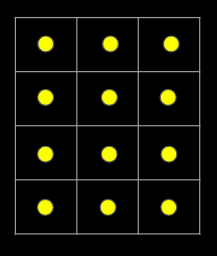

In [39]:
import numpy as np

In [40]:
m = np.array(
[[1, 2, 3, 4, 4, 3, 2, 1],
 [2, 3, 5, 6, 6, 5, 3, 2],
 [3, 5, 7, 8, 8, 7, 5, 3],
 [4, 6, 8,10,10, 8, 6, 4],
 [3, 5, 7, 8, 8, 7, 5, 3],
 [2, 3, 5, 6, 6, 5, 3, 2],
 [1, 2, 3, 4, 4, 3, 2, 1]])

print(m)

[[ 1  2  3  4  4  3  2  1]
 [ 2  3  5  6  6  5  3  2]
 [ 3  5  7  8  8  7  5  3]
 [ 4  6  8 10 10  8  6  4]
 [ 3  5  7  8  8  7  5  3]
 [ 2  3  5  6  6  5  3  2]
 [ 1  2  3  4  4  3  2  1]]


In [41]:
print(m.shape)

(7, 8)


In [42]:
ny = m.shape[0]
nx = m.shape[1]

In [43]:
x0 = 5
x1D = x0 + np.arange(nx)
print(x1D)

[ 5  6  7  8  9 10 11 12]


In [44]:
y0 = 4
y1D = y0 + np.arange(ny)
print(y1D)

[ 4  5  6  7  8  9 10]


¡Los arrays x1D e y1D tienen una dimension!

In [45]:
x2D, y2D = np.meshgrid(x1D, y1D)

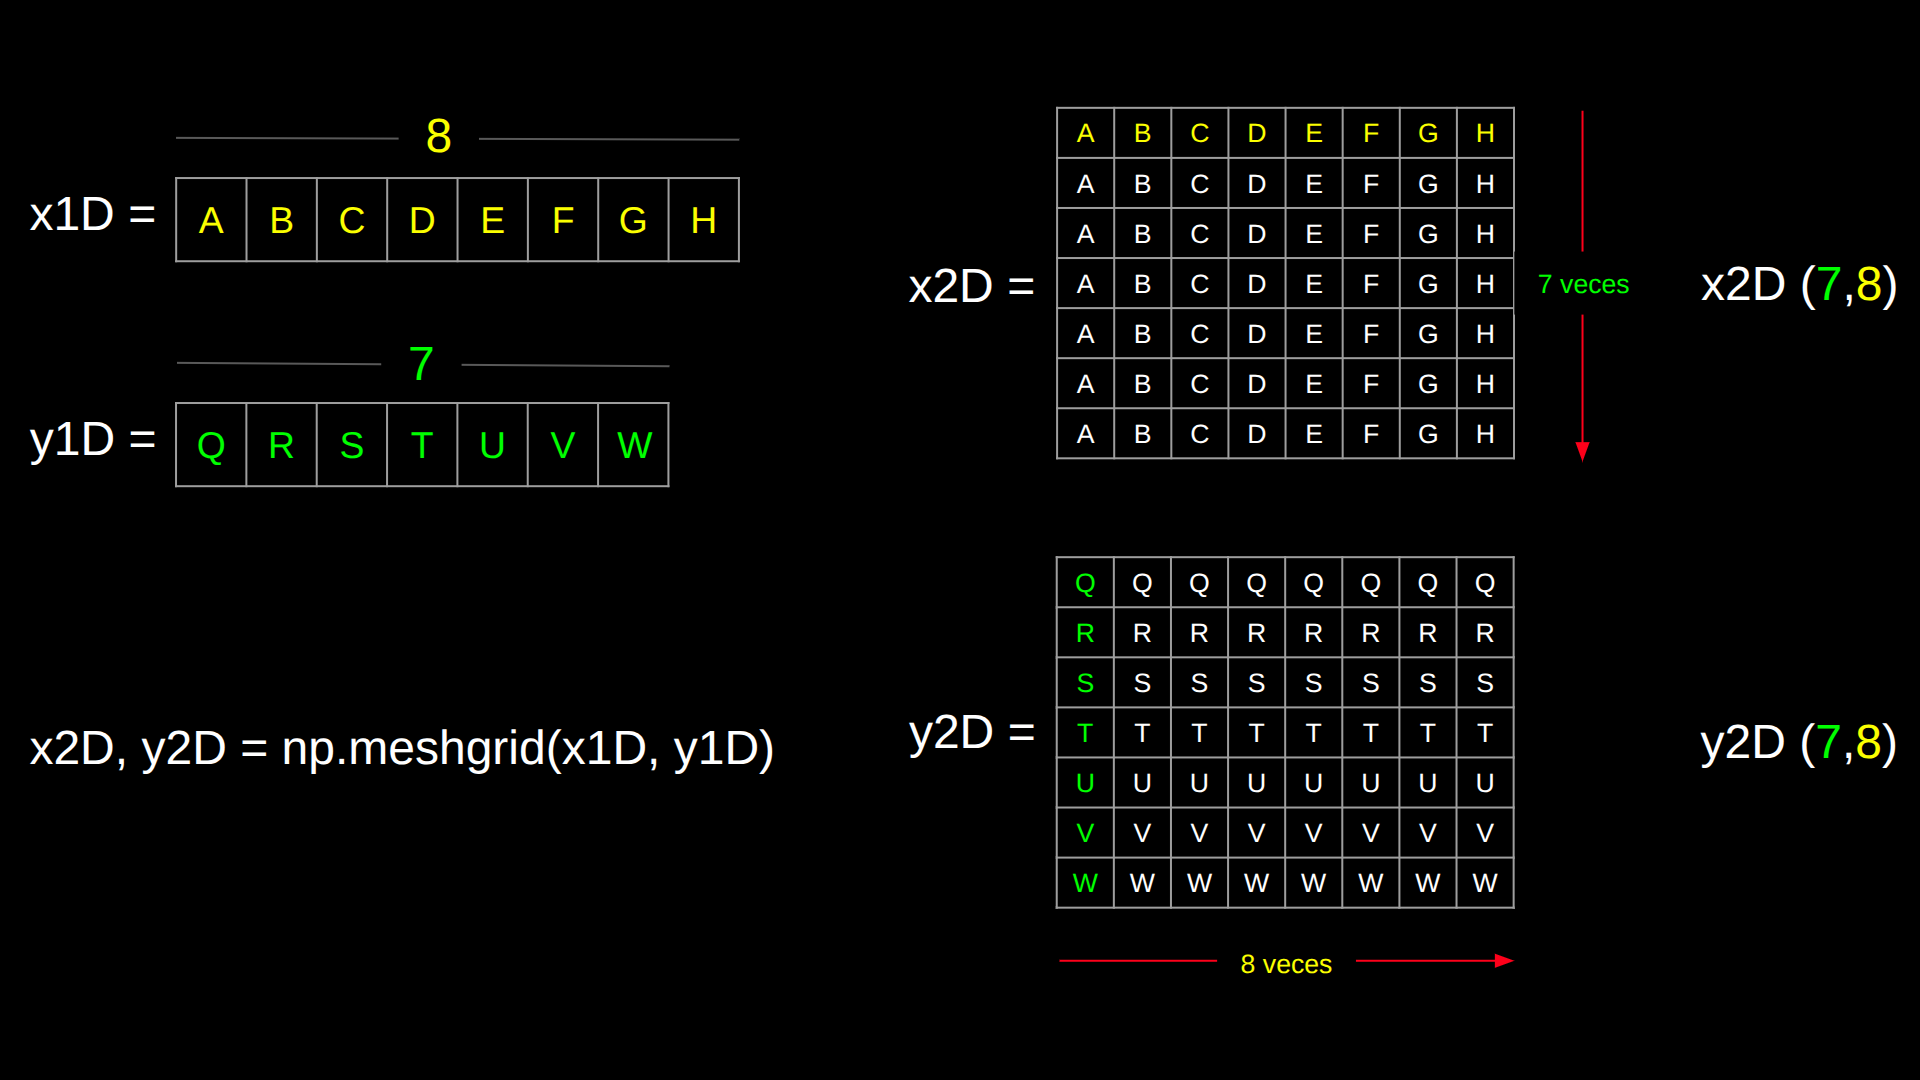

In [46]:
print(x2D)
print(x2D.shape)
print(x2D.ndim)

[[ 5  6  7  8  9 10 11 12]
 [ 5  6  7  8  9 10 11 12]
 [ 5  6  7  8  9 10 11 12]
 [ 5  6  7  8  9 10 11 12]
 [ 5  6  7  8  9 10 11 12]
 [ 5  6  7  8  9 10 11 12]
 [ 5  6  7  8  9 10 11 12]]
(7, 8)
2


In [47]:
print(y2D)
print(y2D.shape)
print(y2D.ndim)

[[ 4  4  4  4  4  4  4  4]
 [ 5  5  5  5  5  5  5  5]
 [ 6  6  6  6  6  6  6  6]
 [ 7  7  7  7  7  7  7  7]
 [ 8  8  8  8  8  8  8  8]
 [ 9  9  9  9  9  9  9  9]
 [10 10 10 10 10 10 10 10]]
(7, 8)
2


In [48]:
print(m)
print(m.shape)
print(m.ndim)

[[ 1  2  3  4  4  3  2  1]
 [ 2  3  5  6  6  5  3  2]
 [ 3  5  7  8  8  7  5  3]
 [ 4  6  8 10 10  8  6  4]
 [ 3  5  7  8  8  7  5  3]
 [ 2  3  5  6  6  5  3  2]
 [ 1  2  3  4  4  3  2  1]]
(7, 8)
2


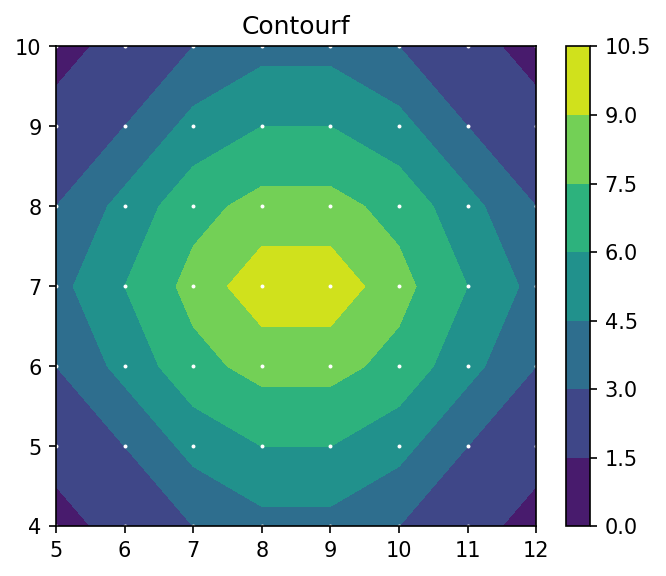

In [49]:
import matplotlib.pyplot as plt

fig = plt.figure('ejemplo', figsize=(5,4), dpi=150)
ax = fig.add_axes([0.1,0.1,0.8,0.8])

img = plt.contourf(x2D, y2D, m, cmap='viridis')
plt.colorbar(img)

plt.scatter(x2D, y2D, c='white', s=0.8)

plt.title('Contourf')

plt.savefig('ejemplo_contourf.png')
plt.show()

## 2. pcolormesh

Realiza un gráfico de cada elemento del array respetando su área de cobertura. Necesita las coordenadas de las esquinas de cada elemento del array a graficar.

En la siguiente imagen las cuadriculas representan el array y los puntos amarillos representan las coordenadas de las esquinas de cada elemento del array.

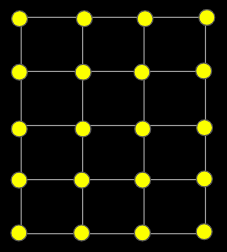

In [50]:
print(x1D)

[ 5  6  7  8  9 10 11 12]


In [51]:
print(y1D)

[ 4  5  6  7  8  9 10]


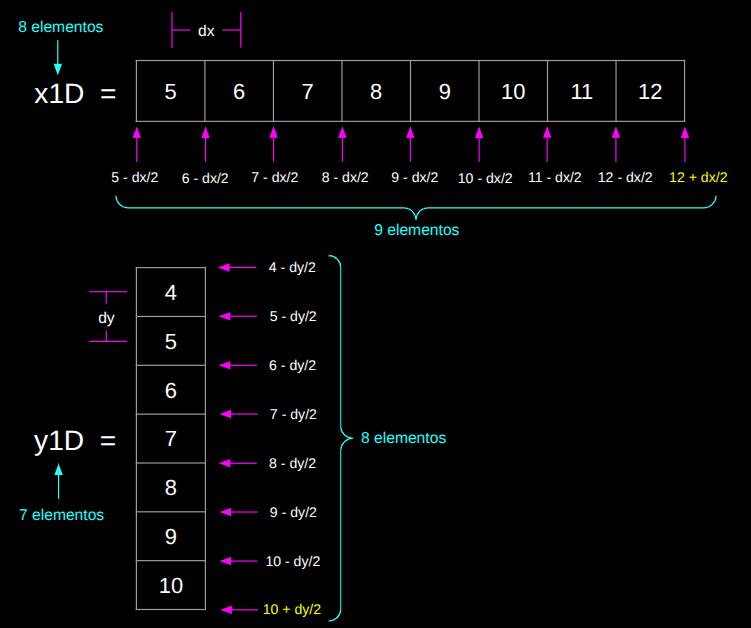

In [52]:
dx = x1D[1]-x1D[0]
dy = y1D[1]-y1D[0]

xf = x1D[-1]+dx/2
yf = y1D[-1]+dy/2

xcor1D = np.concatenate([x1D-dx/2, [xf]])
ycor1D = np.concatenate([y1D-dy/2, [yf]])
xcor2D, ycor2D = np.meshgrid(xcor1D, ycor1D)

In [53]:
print(xcor2D)

[[ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5]
 [ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5]
 [ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5]
 [ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5]
 [ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5]
 [ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5]
 [ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5]
 [ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5]]


In [54]:
print(ycor2D)

[[ 3.5  3.5  3.5  3.5  3.5  3.5  3.5  3.5  3.5]
 [ 4.5  4.5  4.5  4.5  4.5  4.5  4.5  4.5  4.5]
 [ 5.5  5.5  5.5  5.5  5.5  5.5  5.5  5.5  5.5]
 [ 6.5  6.5  6.5  6.5  6.5  6.5  6.5  6.5  6.5]
 [ 7.5  7.5  7.5  7.5  7.5  7.5  7.5  7.5  7.5]
 [ 8.5  8.5  8.5  8.5  8.5  8.5  8.5  8.5  8.5]
 [ 9.5  9.5  9.5  9.5  9.5  9.5  9.5  9.5  9.5]
 [10.5 10.5 10.5 10.5 10.5 10.5 10.5 10.5 10.5]]


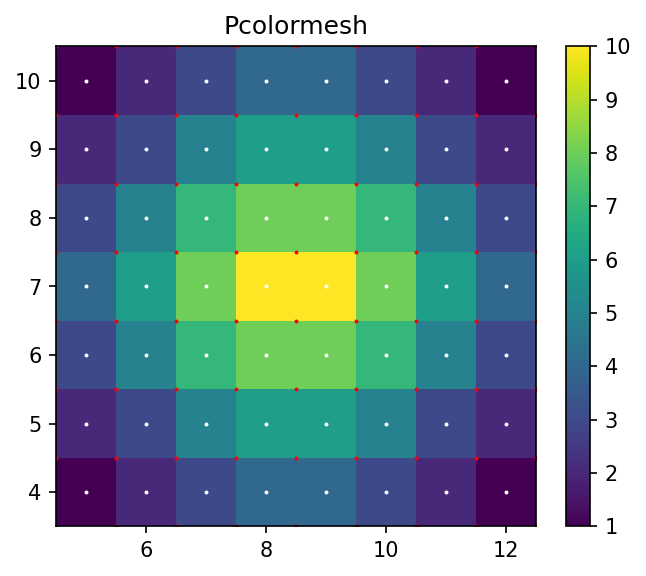

In [55]:
fig = plt.figure('pcolormesh', figsize=(5,4), dpi=150)
ax = fig.add_axes([0.1,0.1,0.8,0.8])

img = plt.pcolormesh(xcor2D, ycor2D, m, cmap='viridis')
plt.colorbar(img)

plt.scatter(x2D, y2D, c='white', s=0.8)
plt.scatter(xcor2D, ycor2D, c='red', s=0.8)

plt.title('Pcolormesh')

plt.savefig('ejemplo_pcolormesh.png')
plt.show()

## 3. imshow

Realiza un gráfico de cada elemento del array pero ajustando su área. Necesita las coordenadas de las esquinas de **todo el array** a graficar.

En la siguiente imagen las cuadriculas representan el array y los puntos amarillos representan la coordenadas de los limites del array.

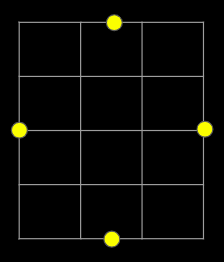

In [56]:
print(xcor1D)

[ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5]


In [57]:
print(xcor1D.min(), xcor1D.max())

4.5 12.5


In [58]:
print(ycor1D)

[ 3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5]


In [59]:
print(ycor1D.min(), ycor1D.max())

3.5 10.5


In [60]:
extent = [xcor1D.min(), xcor1D.max(), ycor1D.min(), ycor1D.max()]
print(extent)

[np.float64(4.5), np.float64(12.5), np.float64(3.5), np.float64(10.5)]


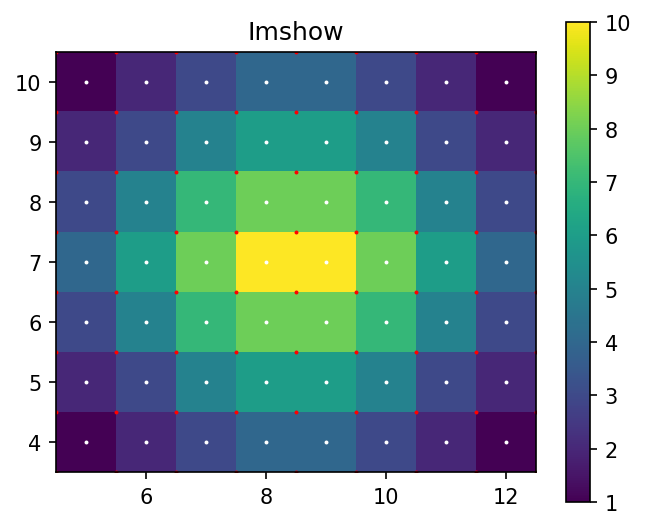

In [61]:
fig = plt.figure('imshow', figsize=(5,4), dpi=150)
ax = fig.add_axes([0.1,0.1,0.8,0.8])

img = plt.imshow(m, extent=extent, origin='lower', cmap='viridis', interpolation='none')
plt.colorbar(img)

plt.scatter(x2D, y2D, c='white', s=0.8)
plt.scatter(xcor2D, ycor2D, c='red', s=0.8)

plt.title('Imshow')

plt.savefig('ejemplo_imshow.png')
plt.show()

Si quisieramos visualizar nuestro array en un plano geográfico necesitamos importar el paquete **cartopy**.

<br>

# **Cartopy**

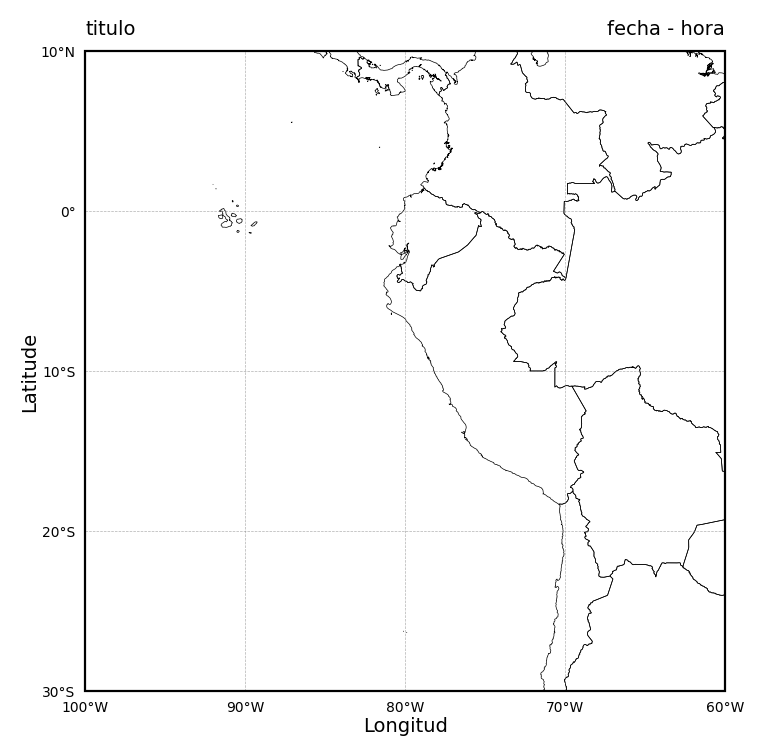

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

lonmin, lonmax = -100.0, -60.0
latmin, latmax = -30.0, 10.0

fig = plt.figure('map', figsize=(4,4), dpi=200)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection=ccrs.PlateCarree())

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='10m', facecolor='none')
ax.add_feature(l, edgecolor='black', linewidth=0.25)

# Aqui graficas el array

ax.set_title('titulo', fontsize=7, loc='left')
ax.set_title('fecha - hora', fontsize=7, loc='right')

xticks = np.arange(-180, 0, 10)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitud', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=False, bottom=True, top=False, labelleft=True, labelright=False,
                         labelbottom=True, labeltop=False, length=0, width=0.05, labelsize=5.0, labelcolor='black')


ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray', draw_labels=False, linewidth=0.25, linestyle='--')

ax.set_xlim(lonmin, lonmax)
ax.set_ylim(latmin, latmax)

plt.show()

Ahora, realicemos un gráfico utilizando los limites guardados en archivos shapefile <br>

En este caso vamos a descargar los shapefiles de mi github:

In [63]:
%%capture
!wget https://raw.githubusercontent.com/joaohenry23/shapefiles/ae59b5947a4afc1fb5743e79acb35e919bbf531c/mundo.zip
!wget https://raw.githubusercontent.com/joaohenry23/shapefiles/0bafda42194d36bd3a53567dc897ef0466ad00f5/depa.zip
!wget https://raw.githubusercontent.com/joaohenry23/shapefiles/0bafda42194d36bd3a53567dc897ef0466ad00f5/prov.zip
!wget https://raw.githubusercontent.com/joaohenry23/shapefiles/0bafda42194d36bd3a53567dc897ef0466ad00f5/dist.zip

!rm -fr shapefiles
!unzip mundo.zip -d shapefiles
!unzip depa.zip -d shapefiles
!unzip prov.zip -d shapefiles
!unzip dist.zip -d shapefiles
!rm -fr *.zip

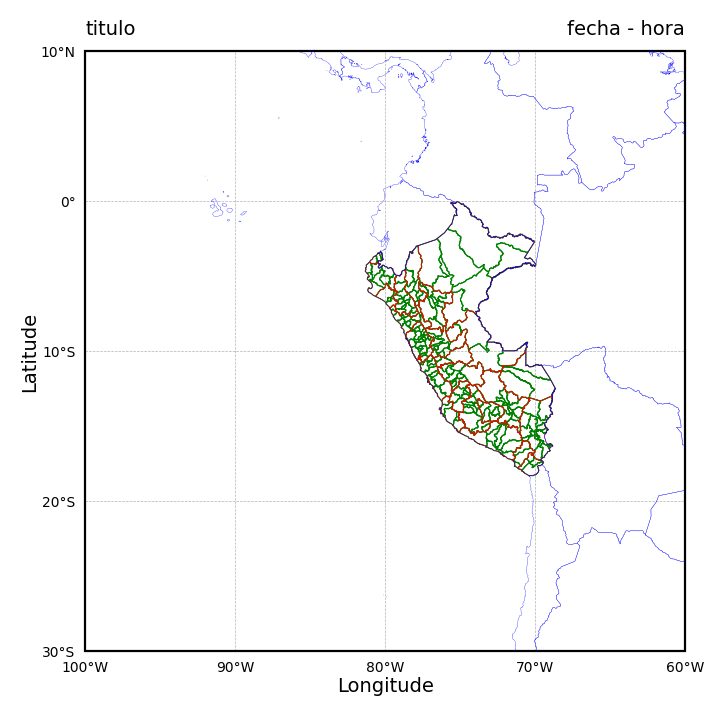

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import cartopy.io.shapereader as shpreader

lonmin, lonmax, latmin, latmax = [-100.0, -60.0, -30.0, 10.0]

# carpeta de los shapefiles
path_shp = 'shapefiles/'

fig = plt.figure('map', figsize=(4,4), dpi=200)
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=ccrs.PlateCarree())

reader = shpreader.Reader(path_shp+'mundo_corregido.shp')
ax.add_geometries(reader.geometries(), ccrs.PlateCarree(), facecolor='none', edgecolor='blue', linewidth=0.1, zorder=3)

reader = shpreader.Reader(path_shp+'depa_18_ign.shp')
ax.add_geometries(reader.geometries(), ccrs.PlateCarree(), facecolor='none', edgecolor='red', linewidth=0.2, zorder=2)

reader = shpreader.Reader(path_shp+'prov_18_ign.shp')
ax.add_geometries(reader.geometries(), ccrs.PlateCarree(), facecolor='none', edgecolor='green', linewidth=0.4, zorder=1)

# Aqui adicionas los campos
ax.set_title('titulo', fontsize=7, loc='left')
ax.set_title('fecha - hora', fontsize=7, loc='right')

xticks = np.arange(-180, 0, 10)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True, labelleft=True, labelright=False,
                         labelbottom=True, labeltop=False, length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray', draw_labels=False, linewidth=0.25, linestyle='--')
ax.set_xlim(lonmin, lonmax)
ax.set_ylim(latmin, latmax)

plt.show()


# Grafiquemos un array sobre un mapa geográfico

In [65]:
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# defino mi array y sus coordenas
lon = np.linspace(-80, 80, 25)
lat = np.linspace(30, 70, 25)
lon2d, lat2d = np.meshgrid(lon, lat)
data = np.cos(np.deg2rad(lat2d) * 4) + np.sin(np.deg2rad(lon2d) * 4)

In [66]:
print(lat2d.shape)
print(lon2d.shape)
print(data.shape)

(25, 25)
(25, 25)
(25, 25)


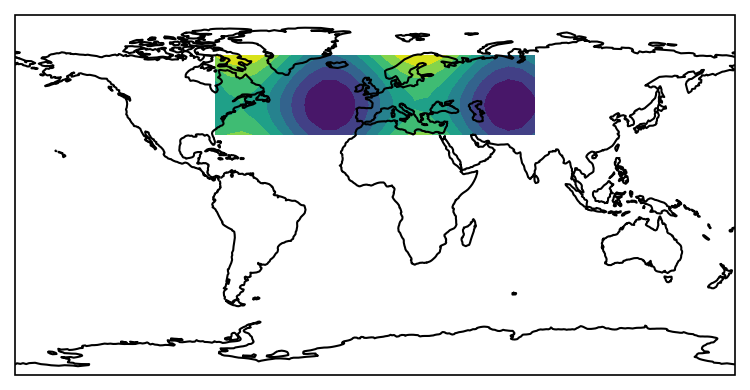

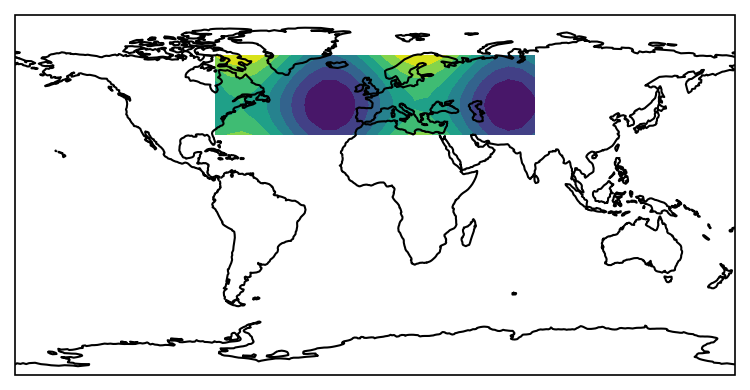

In [67]:
fig = plt.figure('sin transform', figsize=(6, 3), dpi=150)
ax = fig.add_axes([0.1,0.1,0.8,0.8,], projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()
ax.contourf(lon, lat, data)

fig = plt.figure('con transform', figsize=(6, 3), dpi=150)
ax = fig.add_axes([0.1,0.1,0.8,0.8,], projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()
ax.contourf(lon, lat, data, transform=ccrs.PlateCarree())
plt.show()


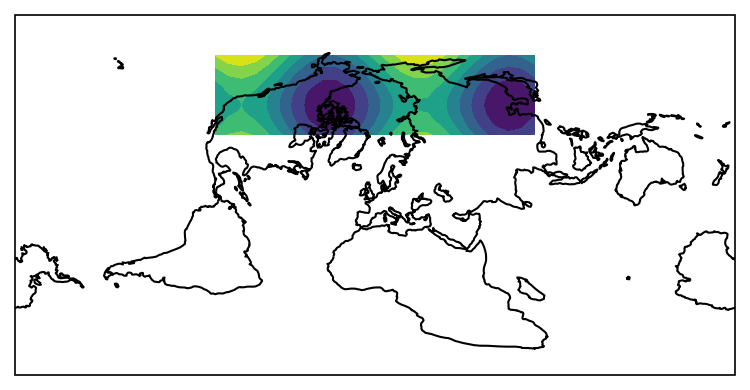

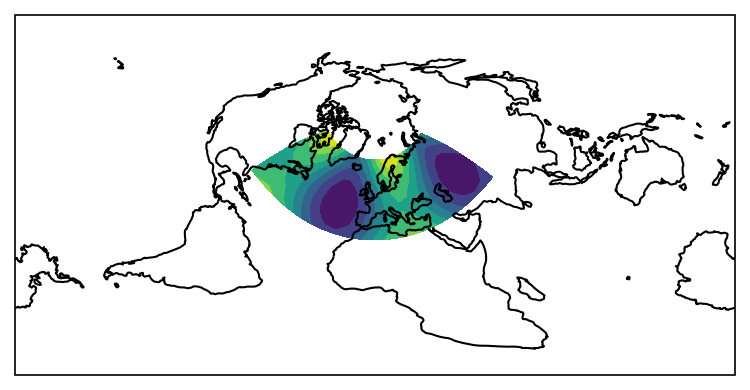

In [68]:
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
lon = np.linspace(-80, 80, 25)
lat = np.linspace(30, 70, 25)
lon2d, lat2d = np.meshgrid(lon, lat)
data = np.cos(np.deg2rad(lat2d) * 4) + np.sin(np.deg2rad(lon2d) * 4)

fig = plt.figure('sin transform', figsize=(6, 3), dpi=150)
ax = fig.add_axes([0.1,0.1,0.8,0.8,], projection=ccrs.RotatedPole(pole_longitude=-177.5, pole_latitude=37.5))
ax.set_global()
ax.coastlines()
ax.contourf(lon, lat, data)

fig = plt.figure('con transform', figsize=(6, 3), dpi=150)
ax = fig.add_axes([0.1,0.1,0.8,0.8,], projection=ccrs.RotatedPole(pole_longitude=-177.5, pole_latitude=37.5))
ax.set_global()
ax.coastlines()
ax.contourf(lon, lat, data, transform=ccrs.PlateCarree())
plt.show()


<br>

## Explicación
El parámetro **projection** indica la proyección del mapa. <br>
El parámetro **transform** convierte las coordenadas de la imagen (**unidades**) en coordenadas geográficas. <br>
La función **ccrs.PlateCarree()** genera una proyección plana, donde las coordenadas decimales de latitud y longitud son considerados como unidades. **No se realiza ninguna transformación.**<br>
```
Ejemplo:
-90.5 longitud decimal es -90.5 unidades
10.25 latitud decimal es 10.25 unidades
```

Si no se define transform, entonces matplotlib entiende que las coordenadas son unidades.<br>
```
Ejemplo:
25.2, 89.3, 12.5
```

#### Por este motivo, si projection = ccrs.PlateCarree(), entonces transform no es necesario. <br>
#### En cambio, si projection ≠ ccrs.PlateCarree(), entonces es **obligatorio** adicionar transform al momento graficar el array.

<BR>

## Graficando un array sobre un plano geográfico

In [69]:
# Generando el dato

import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

In [70]:
lon = np.arange(-100.0, -45.0, 5.0)
lat = np.arange(30.0, -35.0, -5.0)
loncen2d, latcen2d = np.meshgrid(lon, lat)

loncor = np.arange(-100.0, -40.0, 5.0)-2.5
latcor = np.arange(30.0, -40.0, -5.0)+2.5
loncor2d, latcor2d = np.meshgrid(loncor, latcor)

data = np.random.randint(0,101,loncen2d.shape)

lonmin, lonmax, latmin, latmax = [-110.0, -40.0, -35.0, 35.0]

In [71]:
print(loncen2d.shape)
print(latcen2d.shape)
print(data.shape)

(13, 11)
(13, 11)
(13, 11)


In [72]:
print(loncor2d.shape)
print(latcor2d.shape)
print(data.shape)

(14, 12)
(14, 12)
(13, 11)


In [73]:
print(data)

[[ 83  24  54  17  42  95  91  80  68  79  17]
 [ 29  59  98  26   3   2  83  92  26  79  58]
 [ 46  75  77  40  91  49  25  74  88  33  51]
 [ 58   0  68  98  48  13  15  71   8  28   7]
 [ 24  17  39  46  40  22  33  99  54   4  43]
 [ 43  29  29   3  94  29   5   8  77  95  11]
 [ 44  83  98  72  21  48  93 100   5  44  52]
 [ 58  52   7  48  19  56  48  45  38  46  78]
 [  5  53  12  95  14  50  55  12  54  94  35]
 [ 78   3   8  67  99  27   7  34  17  93  60]
 [ 97  21  81  47  25  11  75  79  61  82  47]
 [  9  48  54  50  77  11  37  44   4  93  27]
 [ 10   5  92  79  70   2  84  93  64  17  11]]


Usando **contourf**

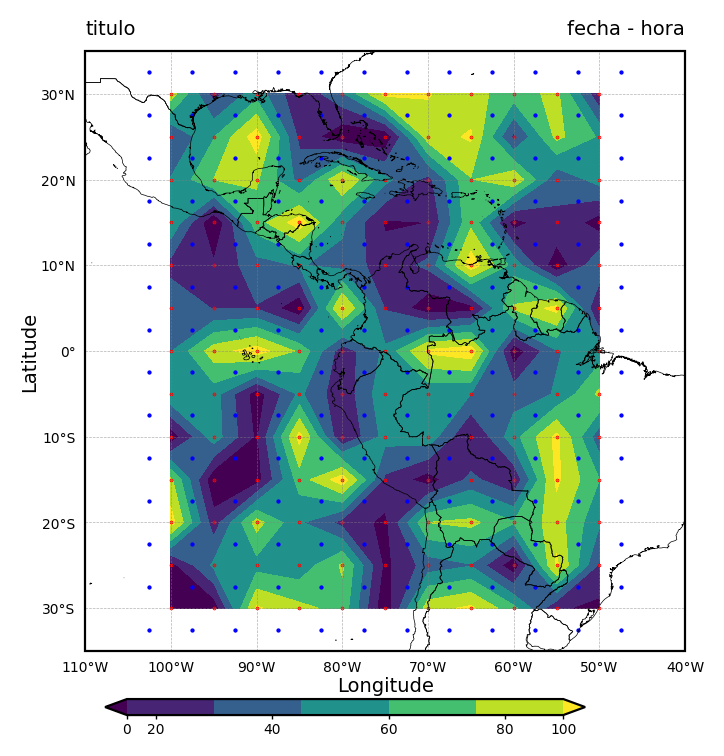

In [74]:
#Graficando el dato

fig = plt.figure('contourf', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=ccrs.PlateCarree()) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='10m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='black', linewidth=0.25) # Adicionamos los limites

img = ax.contourf(loncen2d, latcen2d, data, extend='both', transform=ccrs.PlateCarree()) # Graficamos el dato

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=[0,20,40,60,80,100], orientation='horizontal', cax=fig.add_axes([0.15,0.08,0.6,0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)

pts_cen = ax.scatter(loncen2d, latcen2d, s=0.1, color='red') # Graficamos el centro de cada elemento del dato
pts_cor = ax.scatter(loncor2d, latcor2d, s=0.3, color='blue') # Graficamos las esquinas de cada elemento del dato

# Configuración del titulo
ax.set_title('titulo', fontsize=7, loc='left')
ax.set_title('fecha - hora', fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-180, 0, 10)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True, labelleft=True, labelright=False, labelbottom=True, labeltop=False, length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray', draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(lonmin, lonmax)
ax.set_ylim(latmin, latmax)

plt.show() # Mostramos la figura


Usando **pcolormesh**

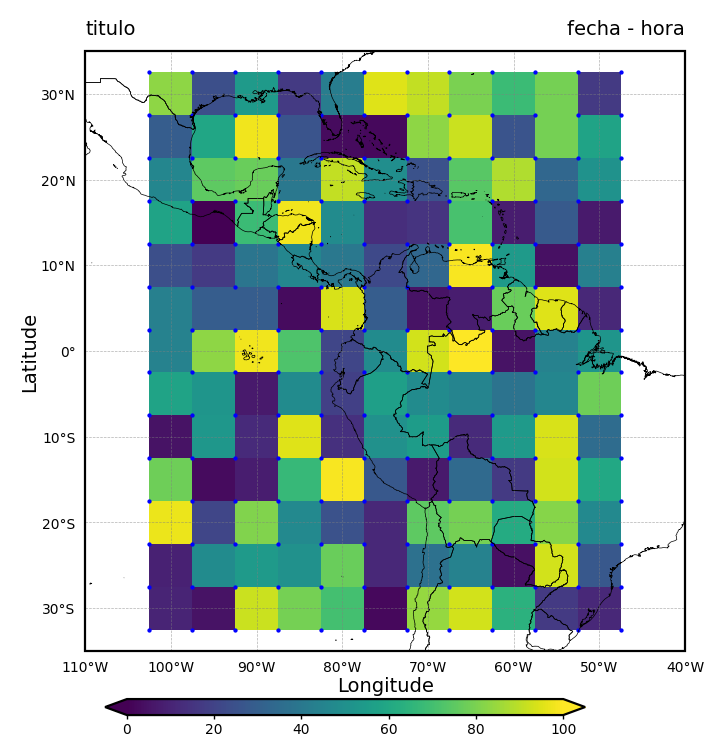

In [75]:
#Graficando el dato

fig = plt.figure('pcolormesh', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=ccrs.PlateCarree()) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='10m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='black', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(loncor2d, latcor2d, data, transform=ccrs.PlateCarree()) # Graficamos el dato

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=[0,20,40,60,80,100], extend='both', orientation='horizontal', cax=fig.add_axes([0.15,0.08,0.6,0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)

#pts_cen = ax.scatter(loncen2d, latcen2d, s=0.1, color='red') # Graficamos el centro de cada elemento del dato
pts_cor = ax.scatter(loncor2d, latcor2d, s=0.3, color='blue') # Graficamos las esquinas de cada elemento del dato

# Configuración del titulo
ax.set_title('titulo', fontsize=7, loc='left')
ax.set_title('fecha - hora', fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-180, 0, 10)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True, labelleft=True, labelright=False, labelbottom=True, labeltop=False, length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray', draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(lonmin, lonmax)
ax.set_ylim(latmin, latmax)

plt.show() # Mostramos la figura


<br>

# **DESCARGA DE DATOS**

## Amazon Web Service

Podemos descargar los datos de forma manual desde el siguiente enlace: https://noaa-goes19.s3.amazonaws.com/index.html

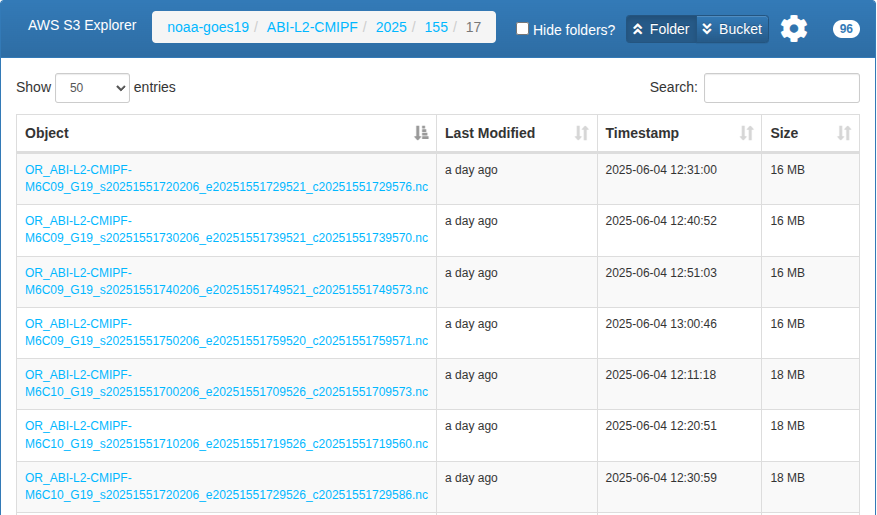


Podemos descargas los datos del GOES-19 con python, utilizando el paquete GOES. <br>

In [76]:
import GOES

In [77]:
GOES.show_products()

 
Products for goes16:
	ABI-L1b-RadC
	ABI-L1b-RadC-Reproc
	ABI-L1b-RadF
	ABI-L1b-RadF-Reproc
	ABI-L1b-RadM
	ABI-L2-ACHA2KMC
	ABI-L2-ACHA2KMF
	ABI-L2-ACHA2KMM
	ABI-L2-ACHAC
	ABI-L2-ACHAF
	ABI-L2-ACHAM
	ABI-L2-ACHP2KMC
	ABI-L2-ACHP2KMF
	ABI-L2-ACHP2KMM
	ABI-L2-ACHTF
	ABI-L2-ACHTM
	ABI-L2-ACMC
	ABI-L2-ACMF
	ABI-L2-ACMM
	ABI-L2-ACTPC
	ABI-L2-ACTPF
	ABI-L2-ACTPM
	ABI-L2-ADPC
	ABI-L2-ADPF
	ABI-L2-ADPM
	ABI-L2-AICEF
	ABI-L2-AITAF
	ABI-L2-AODC
	ABI-L2-AODF
	ABI-L2-BRFC
	ABI-L2-BRFF
	ABI-L2-BRFM
	ABI-L2-CCLC
	ABI-L2-CCLF
	ABI-L2-CCLM
	ABI-L2-CMIPC
	ABI-L2-CMIPF
	ABI-L2-CMIPM
	ABI-L2-COD2KMF
	ABI-L2-CODC
	ABI-L2-CODF
	ABI-L2-CPSC
	ABI-L2-CPSF
	ABI-L2-CPSM
	ABI-L2-CTPC
	ABI-L2-CTPF
	ABI-L2-DMWC
	ABI-L2-DMWF
	ABI-L2-DMWM
	ABI-L2-DMWVC
	ABI-L2-DMWVF
	ABI-L2-DMWVM
	ABI-L2-DSIC
	ABI-L2-DSIF
	ABI-L2-DSIM
	ABI-L2-DSRC
	ABI-L2-DSRF
	ABI-L2-DSRM
	ABI-L2-FDCC
	ABI-L2-FDCF
	ABI-L2-FDCM
	ABI-L2-FSCC
	ABI-L2-FSCF
	ABI-L2-FSCM
	ABI-L2-LSAC
	ABI-L2-LSAF
	ABI-L2-LSAM
	ABI-L2-LST2KMF
	ABI-L2-LSTC
	ABI-L2-LSTF
	A

La descripción de los productos del GOES se encuentra en el siguiente enlace: https://github.com/NOAA-Big-Data-Program/nodd-data-docs/tree/main/GOES

In [78]:
help(GOES.download)

Help on function download in module GOES.downloads.download_data:

download(Satellite, Product, DateTimeIni=None, DateTimeFin=None, domain=None, channel=None, rename_fmt=False, path_out='', retries=10, backoff=10, size_format='Decimal', show_download_progress=True, overwrite_file=False)
    Download data of GOES-16, GOES-17, GOES-18 and GOES-19 from Amazon server.
    This function is based on the code of
    blaylockbk https://gist.github.com/blaylockbk/d60f4fce15a7f0475f975fc57da9104d


    Parameters
    ----------
    Satellite : str
        Indicates serie of GOES, the options are 'goes16', 'goes17', 'goes18' and 'goes19'


    Product : str
        Indicates the instrument and level of product. The products
        can be list using: GOES.show_products()


    DateTimeIni : str
        String that indicates the initial datetime. Its structure
        must be yyyymmdd-HHMMSS
        Example:
            DateTimeIni='20180520-183000'


    DateTimeFin : str
        String that indi

In [79]:
flist = GOES.download('goes19', # satelite
                      'ABI-L2-CMIPF', # producto
                      DateTimeIni='20250606-103000', # Fecha inicio
                      DateTimeFin='20250606-104000', # Fecha de fin
                      channel=['13'],
                      path_out='')

Files:
  OR_ABI-L2-CMIPF-M6C13_G19_s20251571030210_e20251571039530_c20251571039571.nc 100% 23.2MB 0s


En el ejemplo anterior, el archivo se guardó temporalmente en la carpeta /content/. Si quisiéramos guarlo en una ubicación específica dentro de nuestro Google Drive, primero debemos montarlo en nuestro entorno de ejecución mediante el siguiente comando:

In [81]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Luego, debemos crear nuestras carpetas de trabajo:

In [82]:
import os
os.makedirs('/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/',exist_ok=True)

Guardamos los datos en nuestra carpeta:

In [83]:
flist = GOES.download('goes19',
                      'ABI-L2-CMIPF',
                      DateTimeIni='20250606-102000',
                      DateTimeFin='20250606-110100',
                      channel=['13'],
                      path_out='/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/')

Files:
  OR_ABI-L2-CMIPF-M6C13_G19_s20251571020210_e20251571029530_c20251571029571.nc already exists.
  OR_ABI-L2-CMIPF-M6C13_G19_s20251571030210_e20251571039530_c20251571039571.nc already exists.
  OR_ABI-L2-CMIPF-M6C13_G19_s20251571040210_e20251571049532_c20251571049561.nc already exists.
  OR_ABI-L2-CMIPF-M6C13_G19_s20251571050210_e20251571059531_c20251571059571.nc already exists.
  OR_ABI-L2-CMIPF-M6C13_G19_s20251571100210_e20251571109530_c20251571109570.nc already exists.


In [84]:
print(flist)

['/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571020210_e20251571029530_c20251571029571.nc', '/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571030210_e20251571039530_c20251571039571.nc', '/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571040210_e20251571049532_c20251571049561.nc', '/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571050210_e20251571059531_c20251571059571.nc', '/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571100210_e20251571109530_c20251571109570.nc']


La lista de los archivos descargados se encuentra guardado en de la variable **flist**:

In [85]:
for filename in flist:
    print(filename)

/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571020210_e20251571029530_c20251571029571.nc
/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571030210_e20251571039530_c20251571039571.nc
/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571040210_e20251571049532_c20251571049561.nc
/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571050210_e20251571059531_c20251571059571.nc
/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571100210_e20251571109530_c20251571109570.nc


In [86]:
# imprimiendo el nombre de uno de los archivos
print(f'\nEligiendo el archivo: {flist[1]}')


Eligiendo el archivo: /content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251571030210_e20251571039530_c20251571039571.nc


<br>

# **Lectura de los archivos netcdf**

Veamos el contenido del archivo ".nc", utilizando el paquete NetCDF4.

In [87]:
from netCDF4 import Dataset

ds = Dataset(flist[2])

In [88]:
print(ds)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    naming_authority: gov.nesdis.noaa
    Conventions: CF-1.7
    Metadata_Conventions: Unidata Dataset Discovery v1.0
    standard_name_vocabulary: CF Standard Name Table (v35, 20 July 2016)
    institution: DOC/NOAA/NESDIS > U.S. Department of Commerce, National Oceanic and Atmospheric Administration, National Environmental Satellite, Data, and Information Services
    project: GOES
    production_site: RBU
    production_environment: OE
    spatial_resolution: 2km at nadir
    orbital_slot: GOES-East
    platform_ID: G19
    instrument_type: GOES-R Series Advanced Baseline Imager (ABI)
    scene_id: Full Disk
    instrument_ID: FM4
    dataset_name: OR_ABI-L2-CMIPF-M6C13_G19_s20251571040210_e20251571049532_c20251571049561.nc
    iso_series_metadata_id: 8c9e8150-3692-11e3-aa6e-0800200c9a66
    title: ABI L2 Cloud and Moisture Imagery
    summary: Single emissive band Cloud and Moisture Imagery Products are d

El paquete netCDF4 tiene una clase llamada **Dataset** que crea un *objeto*, el cual contiene atributos y metodos. Este objeto tiene 4 tipos de atributos: **atributs**, **variables**, **dimensions** y **grups**.

<br>

1. **atributs:** <br>
son atributos globales que presenta el objeto creado por la clase **Dataset**. Pueden ser del tipo **string** (**str**) o numérico (entero: **int** o flotante: **float**). Podemos listarlos utilizando el metodo ```ncattrs()```:

In [89]:
ds.ncattrs()

['naming_authority',
 'Conventions',
 'Metadata_Conventions',
 'standard_name_vocabulary',
 'institution',
 'project',
 'production_site',
 'production_environment',
 'spatial_resolution',
 'orbital_slot',
 'platform_ID',
 'instrument_type',
 'scene_id',
 'instrument_ID',
 'dataset_name',
 'iso_series_metadata_id',
 'title',
 'summary',
 'keywords',
 'keywords_vocabulary',
 'license',
 'processing_level',
 'date_created',
 'cdm_data_type',
 'time_coverage_start',
 'time_coverage_end',
 'timeline_id',
 'production_data_source',
 'id']

In [90]:
print(ds.platform_ID)

G19


También podemos usar el metodo ```getncattr()``` para obtener el valor del atributo:

In [91]:
print(ds.getncattr('platform_ID'))

G19


<br>

2. **variables:** <br>
son atributos contenedores tipo mapping (presenta un key - value similar a los *dictionary* (**dict**)). Por tanto, si queremos conocer su contenido debemos utilizar el metodo que utilizamos con los diccionarios: ```keys()```. <br>
Para conocer todas las variables del archivo utilizamos: ```variables.keys()```.

In [92]:
print(*ds.variables.keys(),sep='\n')

CMI
DQF
t
y
x
time_bounds
goes_imager_projection
y_image
y_image_bounds
x_image
x_image_bounds
nominal_satellite_subpoint_lat
nominal_satellite_subpoint_lon
nominal_satellite_height
geospatial_lat_lon_extent
band_wavelength
band_id
total_number_of_points
valid_pixel_count
outlier_pixel_count
min_brightness_temperature
max_brightness_temperature
mean_brightness_temperature
std_dev_brightness_temperature
planck_fk1
planck_fk2
planck_bc1
planck_bc2
algorithm_dynamic_input_data_container
percent_uncorrectable_GRB_errors
percent_uncorrectable_L0_errors
earth_sun_distance_anomaly_in_AU
processing_parm_version_container
algorithm_product_version_container
esun
kappa0
focal_plane_temperature_threshold_exceeded_count
maximum_focal_plane_temperature
focal_plane_temperature_threshold_increasing
focal_plane_temperature_threshold_decreasing
channel_integration_time
channel_gain_field


Imprimimos el contenido de la variable "CMI":

In [95]:
print(ds.variables['CMI'])

<class 'netCDF4.Variable'>
int16 CMI(y, x)
    _FillValue: -1
    long_name: ABI L2+ Cloud and Moisture Imagery brightness temperature
    standard_name: toa_brightness_temperature
    _Unsigned: true
    sensor_band_bit_depth: 12
    valid_range: [   0 4095]
    scale_factor: 0.06145332
    add_offset: 89.62
    units: K
    resolution: y: 0.000056 rad x: 0.000056 rad
    coordinates: band_id band_wavelength t y x
    grid_mapping: goes_imager_projection
    cell_methods: t: point area: point
    ancillary_variables: DQF
unlimited dimensions: 
current shape = (5424, 5424)
filling on


<br>

3. **dimensions:** <br>
son atributos contenedores tipo mapping (presenta un key - value similar a los *dictionary* (**dict**)) que guardan la información de las dimensiones de las variables.

In [96]:
print(*ds.dimensions.keys(), sep='\n')

y
x
number_of_time_bounds
band
number_of_image_bounds


In [97]:
print(ds.dimensions['x'])

"<class 'netCDF4.Dimension'>": name = 'x', size = 5424


In [98]:
print(ds.dimensions['x'].size)

5424


<br>

4. **grups:** <br>
son atributos contenedores tipo mapping (presenta un key - value similar a los *dictionary* (**dict**)) pero estructurados de forma jerárquicas (similares a carpetas). <br>
Son especialmente útiles cuando se necesita separar diferentes conjuntos de datos relacionados, como por ejemplo, datos por región (region_norte, region_sur). <br>
Estos contenedores albergan objetos similares a los creados por la función **Dataset**, es decir presentan **atributs**, **variables**, **dimensions** y **groups**.

```
   /
   ├── atributos: titulo, autor, descripción
   ├── dimensiones: time, lat, lon
   ├── variables: temperatura_global
   ├── grupo: region_norte
   │   ├── dimensiones: time, lat, lon
   │   ├── variables: temperatura_local, humedad_local
   ├── grupo: region_sur
       ├── dimensiones: time, lat, lon
       ├── variables: temperatura_local, presion_local
```

En nuestro archivo no contamos con **groups**.

In [99]:
print(ds.groups.keys())

dict_keys([])


<br>

# Resumiendo

```
Objeto de Dataset (archivo NetCDF)
|
|-- atributs (atributos globales)
|     |-- strings
|     |-- numeros (int, float, etc)
|
|-- variables  (atributo: contenedor tipo mapping)
|     |
|     |-- nombre_variable  -->  Variable (objeto especial)
|           |-- atributos (units, long_name, etc)
|           |-- array de datos (NumPy-like)
|
|-- dimensions (atributo: contenedor tipo mapping)
|     |
|     |-- nombre_dimension -->  Dimension (objeto especial)
|           |-- tamaño
|           |-- tipo de dimension (ilimitada / no ilimitada)
|
|-- groups (atributo: contenedor tipo mapping)
      |
      |-- nombre_grupo --> Objeto de Dataset (subgrupo)
            |-- atributos
            |-- variables   (mapping)
            |-- dimensions  (mapping)
            |-- groups      (mapping)
```


<br>

## Volvamos nuevamente al archivo:

In [100]:
print(ds)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    naming_authority: gov.nesdis.noaa
    Conventions: CF-1.7
    Metadata_Conventions: Unidata Dataset Discovery v1.0
    standard_name_vocabulary: CF Standard Name Table (v35, 20 July 2016)
    institution: DOC/NOAA/NESDIS > U.S. Department of Commerce, National Oceanic and Atmospheric Administration, National Environmental Satellite, Data, and Information Services
    project: GOES
    production_site: RBU
    production_environment: OE
    spatial_resolution: 2km at nadir
    orbital_slot: GOES-East
    platform_ID: G19
    instrument_type: GOES-R Series Advanced Baseline Imager (ABI)
    scene_id: Full Disk
    instrument_ID: FM4
    dataset_name: OR_ABI-L2-CMIPF-M6C13_G19_s20251571040210_e20251571049532_c20251571049561.nc
    iso_series_metadata_id: 8c9e8150-3692-11e3-aa6e-0800200c9a66
    title: ABI L2 Cloud and Moisture Imagery
    summary: Single emissive band Cloud and Moisture Imagery Products are d

Imprimamos las variables nuevamente:

In [101]:
print(*ds.variables.keys(), sep='\n')

CMI
DQF
t
y
x
time_bounds
goes_imager_projection
y_image
y_image_bounds
x_image
x_image_bounds
nominal_satellite_subpoint_lat
nominal_satellite_subpoint_lon
nominal_satellite_height
geospatial_lat_lon_extent
band_wavelength
band_id
total_number_of_points
valid_pixel_count
outlier_pixel_count
min_brightness_temperature
max_brightness_temperature
mean_brightness_temperature
std_dev_brightness_temperature
planck_fk1
planck_fk2
planck_bc1
planck_bc2
algorithm_dynamic_input_data_container
percent_uncorrectable_GRB_errors
percent_uncorrectable_L0_errors
earth_sun_distance_anomaly_in_AU
processing_parm_version_container
algorithm_product_version_container
esun
kappa0
focal_plane_temperature_threshold_exceeded_count
maximum_focal_plane_temperature
focal_plane_temperature_threshold_increasing
focal_plane_temperature_threshold_decreasing
channel_integration_time
channel_gain_field


Como mencionamos anteriormente, las **variables** son atributos de tipo **dictionary**. Estos diccionarios contienen **objetos**. En este caso en particular, estos objetos estan consituidos de 2 partes: **atributos** y **numpy.ndarray**.

**1. Atributos** <br>
Atributos del tipo **string** (**str**) o numérico (entero: **int** o flotante: **float**).

In [102]:
print(ds.variables['CMI'])

<class 'netCDF4.Variable'>
int16 CMI(y, x)
    _FillValue: -1
    long_name: ABI L2+ Cloud and Moisture Imagery brightness temperature
    standard_name: toa_brightness_temperature
    _Unsigned: true
    sensor_band_bit_depth: 12
    valid_range: [   0 4095]
    scale_factor: 0.06145332
    add_offset: 89.62
    units: K
    resolution: y: 0.000056 rad x: 0.000056 rad
    coordinates: band_id band_wavelength t y x
    grid_mapping: goes_imager_projection
    cell_methods: t: point area: point
    ancillary_variables: DQF
unlimited dimensions: 
current shape = (5424, 5424)
filling on


Para obtener la lista de atributos usamos el metodo ```ncattrs()```:

In [103]:
print(ds.variables['CMI'].ncattrs())

['_FillValue', 'long_name', 'standard_name', '_Unsigned', 'sensor_band_bit_depth', 'valid_range', 'scale_factor', 'add_offset', 'units', 'resolution', 'coordinates', 'grid_mapping', 'cell_methods', 'ancillary_variables']


Listemos los atributos pero uno por uno:

In [104]:
print(*ds.variables['CMI'].ncattrs(), sep='\n')

_FillValue
long_name
standard_name
_Unsigned
sensor_band_bit_depth
valid_range
scale_factor
add_offset
units
resolution
coordinates
grid_mapping
cell_methods
ancillary_variables


Imprimamos el valor de uno de los atributos:

In [107]:
print(ds.variables['CMI'].long_name)

ABI L2+ Cloud and Moisture Imagery brightness temperature


**2. numpy.ndarray** <br>
es un arreglo multidimensional que contiene la información medida por el sensor. Para acceder a ello debemos utilizar ```[:]```.

In [108]:
print(ds.variables['CMI'][:])

[[-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 ...
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]]


El **numpy.ndarray** también es un objeto y por lo tanto tiene atributos y metodos.

In [109]:
print(ds.variables['CMI'][:].dtype)

float32


In [110]:
print(ds.variables['CMI'][:].sum())

6379016000.0


# Resumiendo

```
Objeto de Dataset (archivo NetCDF)
|
|-- atributs (atributos globales)
|     |-- strings
|     |-- numeros (int, float, etc)
|
|-- variables  (atributo: contenedor tipo mapping)
|     |
|     |-- CMI -->  Variable (objeto especial)
|           |-- atributos (units, long_name, etc)
|           |-- array de datos (NumPy-like)
|
|-- dimensions (atributo: contenedor tipo mapping)
|     |
|     |-- nombre_dimension -->  Dimension (objeto especial)
|           |-- tamaño
|           |-- tipo de dimension (ilimitada / no ilimitada)
|
|-- groups (atributo: contenedor tipo mapping)
      |
      |-- nombre_grupo --> Objeto de Dataset (subgrupo)
            |-- atributos
            |-- variables   (mapping)
            |-- dimensions  (mapping)
            |-- groups      (mapping)
```

En este caso, este objeto es un array enmascarado (**numpy.ma.MaskedArray**) que es una estructura útil cuando se trabaja con datos numéricos que pueden tener valores inválidos, ausentes o faltantes. Para visualizar **todos** sus elementos usamos:

In [111]:
print(ds.variables['CMI'][:].__repr__)

<bound method MaskedArray.__repr__ of masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=np.uint16(65535),
  dtype=float32)>


El ```numpy.ma.MaskedArray``` esta conformado por:
- **data=[[--, --, ..., --]]**: representa los valores del array, pero enmascarados. Internamente, esos valores aún están en el arreglo, pero no se usan en cálculos a menos que se les indique.
- **mask=[[True, True, ..., True]]**: máscara booleana que indica qué elementos están enmascarados
- **fill_value=np.uint16(65535)**: Es el valor que se usa para rellenar los valores enmascarados cuando se exporta o imprime el arreglo como si no tuviera máscara.
- **dtype=float32**: Tipo de datos almacenados (en este caso, float32)

Si queremos imprimir el array sin la mascara, escribimos:

In [114]:
print(ds.variables['CMI'][:].data)

[[65535. 65535. 65535. ... 65535. 65535. 65535.]
 [65535. 65535. 65535. ... 65535. 65535. 65535.]
 [65535. 65535. 65535. ... 65535. 65535. 65535.]
 ...
 [65535. 65535. 65535. ... 65535. 65535. 65535.]
 [65535. 65535. 65535. ... 65535. 65535. 65535.]
 [65535. 65535. 65535. ... 65535. 65535. 65535.]]


In [115]:
print(ds.variables['CMI'][:].shape)

(5424, 5424)


Imprimiendo una subregión del array:

In [118]:
print(ds.variables['CMI'][2500:2505,2500:2506].data - 273.15)

[[-54.60092  -54.23221  -54.78528  -54.109314 -50.72937  -49.193024]
 [-54.78528  -54.60092  -55.215454 -54.60092  -53.1875   -49.991913]
 [-55.276917 -55.64563  -55.707092 -55.09256  -55.276917 -54.908203]
 [-55.522736 -55.461273 -55.33838  -56.321625 -56.137268 -56.137268]
 [-55.461273 -55.76854  -56.260162 -56.7518   -56.321625 -55.76854 ]]


El ```numpy.ma.MaskedArray``` es la información que nosotros vamos a graficar. Para hacerlo necesitamos importar las librerias **matplotlib** y **cartopy**.

#GRAFICANDO IMAGENES DEL ABI

# Graficando una imagen del ABI con **imshow**

In [119]:
from netCDF4 import Dataset

ds = Dataset(flist[2])

print(ds)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    naming_authority: gov.nesdis.noaa
    Conventions: CF-1.7
    Metadata_Conventions: Unidata Dataset Discovery v1.0
    standard_name_vocabulary: CF Standard Name Table (v35, 20 July 2016)
    institution: DOC/NOAA/NESDIS > U.S. Department of Commerce, National Oceanic and Atmospheric Administration, National Environmental Satellite, Data, and Information Services
    project: GOES
    production_site: RBU
    production_environment: OE
    spatial_resolution: 2km at nadir
    orbital_slot: GOES-East
    platform_ID: G19
    instrument_type: GOES-R Series Advanced Baseline Imager (ABI)
    scene_id: Full Disk
    instrument_ID: FM4
    dataset_name: OR_ABI-L2-CMIPF-M6C13_G19_s20251571040210_e20251571049532_c20251571049561.nc
    iso_series_metadata_id: 8c9e8150-3692-11e3-aa6e-0800200c9a66
    title: ABI L2 Cloud and Moisture Imagery
    summary: Single emissive band Cloud and Moisture Imagery Products are d

In [121]:
print(ds.variables['CMI'])

<class 'netCDF4.Variable'>
int16 CMI(y, x)
    _FillValue: -1
    long_name: ABI L2+ Cloud and Moisture Imagery brightness temperature
    standard_name: toa_brightness_temperature
    _Unsigned: true
    sensor_band_bit_depth: 12
    valid_range: [   0 4095]
    scale_factor: 0.06145332
    add_offset: 89.62
    units: K
    resolution: y: 0.000056 rad x: 0.000056 rad
    coordinates: band_id band_wavelength t y x
    grid_mapping: goes_imager_projection
    cell_methods: t: point area: point
    ancillary_variables: DQF
unlimited dimensions: 
current shape = (5424, 5424)
filling on


In [120]:
print(ds.variables['CMI'][:])

[[-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 ...
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]]


In [122]:
print(ds.variables['y'][:])

[ 0.151844  0.151788  0.151732 ... -0.151732 -0.151788 -0.151844]


In [123]:
print(ds.variables['x'][:])

[-0.151844 -0.151788 -0.151732 ...  0.151732  0.151788  0.151844]


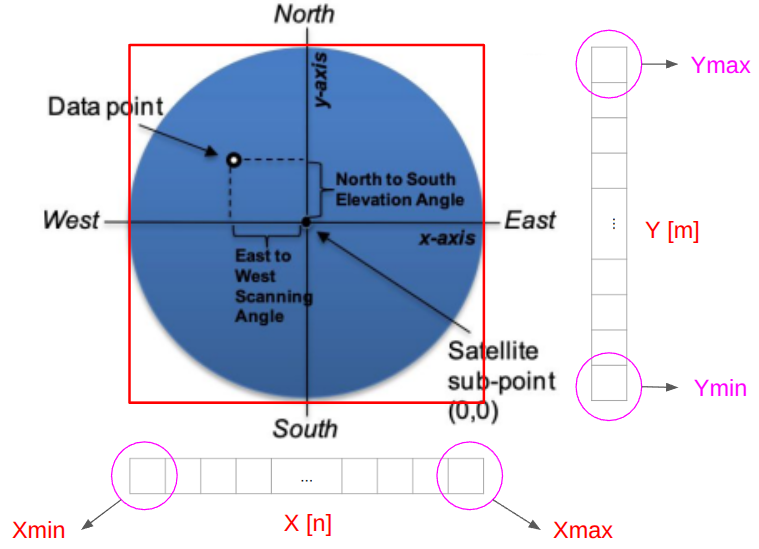

In [124]:
# Obteniendo el dato (imagen de satélite)

from netCDF4 import Dataset

ds = Dataset(flist[2]) # Leemos el archivo nc

# Parametros para obtener las coordenadas del dato (imagen de satélite)
hsat = ds.variables['goes_imager_projection'].perspective_point_height
lon_sat = ds.variables['goes_imager_projection'].longitude_of_projection_origin
x = ds.variables['x'][:]
y = ds.variables['y'][:]
extent = [x.min()*hsat, x.max()*hsat, y.min()*hsat, y.max()*hsat]

# Dato (imagen de satélite) que vamos a graficar
tb = ds.variables['CMI'][:]

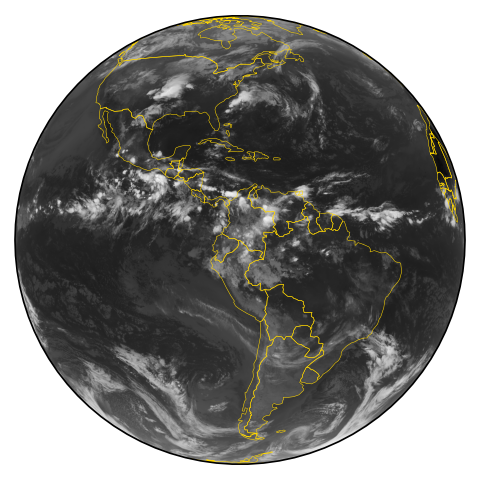

In [125]:
# Graficando el dato (imagen de satélite)

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
import matplotlib.pyplot as plt

proj_fig = ccrs.Geostationary(central_longitude=lon_sat, satellite_height=hsat) # Proyección de la figura
proj_sat = ccrs.Geostationary(central_longitude=lon_sat, satellite_height=hsat) # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=150) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='110m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

ax.imshow(tb, transform=proj_sat, extent=extent, origin='upper', cmap='gray_r', vmin=190.0, vmax=310.0) # Graficamos el dato

plt.savefig('exemplo_plot_imshow.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [126]:
del tb, x, y, ds

Mejorando la presentación

In [127]:
# Obteniendo el dato (imagen de satélite)

import numpy as np
from netCDF4 import Dataset

ds = Dataset(flist[2]) # Leemos el archivo nc

# Atributos del dato (imagen de satélite)
sat = ds.platform_ID
time = ds.time_coverage_start
band_id = ds.variables['band_id'][0]
wl = ds.variables['band_wavelength'][0]
long_name = ds.variables['CMI'].long_name
units = ds.variables['CMI'].units

# Parametros para obtener las coordenadas del dato (imagen de satélite)
hsat = ds.variables['goes_imager_projection'].perspective_point_height
lon_sat = ds.variables['goes_imager_projection'].longitude_of_projection_origin

x = ds.variables['x'][:]
y = ds.variables['y'][:]
extent = [x.min()*hsat, x.max()*hsat, y.min()*hsat, y.max()*hsat]

# Dato (imagen de satélite) que vamos a graficar
tb = ds.variables['CMI'][:]

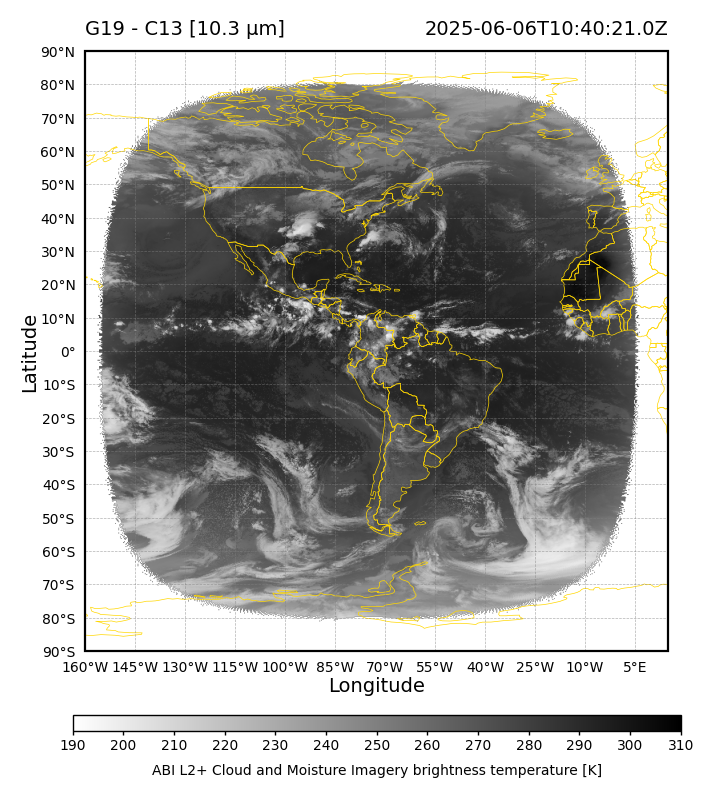

In [128]:
# Graficando el dato (imagen de satélite)

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

domain = [-160.0, 15.0, -90.0, 90.0] # Definimos el dominio de longitud y latitud
proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.Geostationary(central_longitude=lon_sat, satellite_height=hsat) # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='110m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.imshow(tb, transform=proj_sat, extent=extent, origin='upper', cmap='gray_r', vmin=190.0, vmax=310.0) # Graficamos el dato

# Configuración de la barra de colores
ticks = np.arange(190, 320, 10)
cb = plt.colorbar(img, ticks=ticks, orientation='horizontal', cax=fig.add_axes([0.12, 0.06, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - C{} [{:.1f} μm]'.format(sat, band_id, wl), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_imshow.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [129]:
del tb, x, y, ds

<br>

# Graficando una imagen del ABI con **contourf**

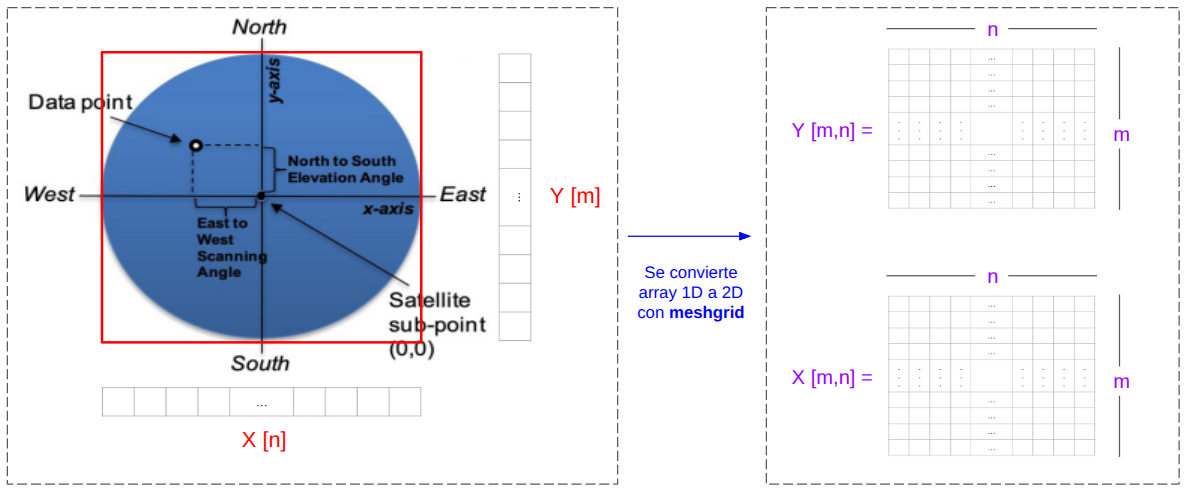

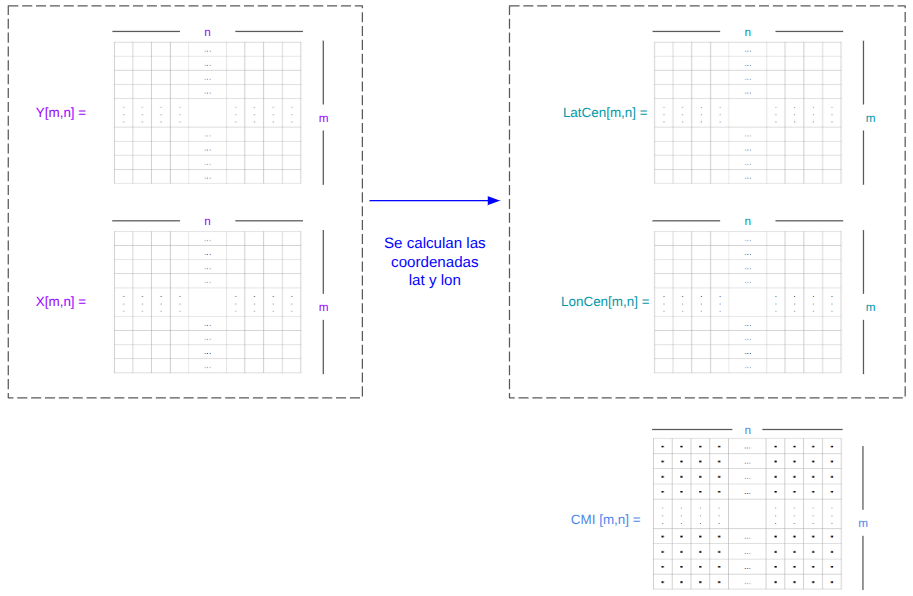

In [130]:
# Obteniendo el dato (imagen de satelite)

import numpy as np
from netCDF4 import Dataset
from pyproj import Proj

ds = Dataset(flist[2]) # Leemos el archivo nc

# Atributos del dato (imagen de satélite)
sat = ds.platform_ID
time = ds.time_coverage_start
band_id = ds.variables['band_id'][0]
wl = ds.variables['band_wavelength'][0]
long_name = ds.variables['CMI'].long_name
units = ds.variables['CMI'].units

# Parametros para obtener las coordenadas del dato (imagen de satélite)
hsat = ds.variables['goes_imager_projection'].perspective_point_height
lon_sat = ds.variables['goes_imager_projection'].longitude_of_projection_origin
sat_sweep = ds.variables['goes_imager_projection'].sweep_angle_axis

x = ds.variables['x'][:]
y = ds.variables['y'][:]

X = x*hsat
Y = y*hsat
X, Y = np.meshgrid(X, Y)
proj = Proj(proj='geos', h=hsat, lon_0=lon_sat, sweep=sat_sweep)
Lons, Lats = proj(X, Y, inverse=True)
Lons = np.where((Lons>=-180.0)&(Lons<=180.0)&(Lats>=-90.0)&(Lats<=90.0),Lons,-999.99).astype(np.float32)
Lats = np.where((Lons>=-180.0)&(Lons<=180.0)&(Lats>=-90.0)&(Lats<=90.0),Lats,-999.99).astype(np.float32)

# Dato (imagen de satélite) que vamos a graficar
tb = ds.variables['CMI'][:]

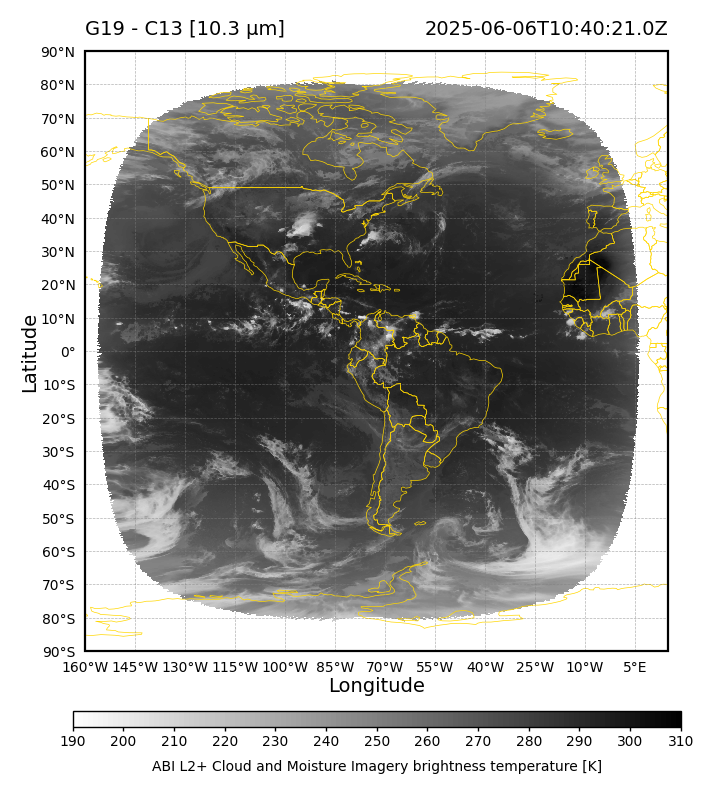

In [131]:
# Graficando el dato (imagen de satélite)

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

domain = [-160.0, 15.0, -90.0, 90.0] # Definimos el dominio de longitud y latitud
proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='110m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.contourf(Lons, Lats, tb, transform=proj_sat, levels=np.arange(190, 311, 1), cmap='gray_r', vmin=190.0, vmax=310.0) # Graficamos el dato

# Configuración de la barra de colores
ticks = np.arange(190, 320, 10)
cb = plt.colorbar(img, ticks=ticks, orientation='horizontal', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - C{} [{:.1f} μm]'.format(sat, band_id, wl), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_contourf.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [132]:
del Lons, Lats, tb, ds, x, y, X, Y, proj

<br>

Simplifiquemos pasos con el paquete **GOES**

In [133]:
# Obteniendo el dato (imagen de satélite)

import GOES

ds = GOES.open_dataset(flist[2]) # Leemos el archivo nc

# Obtenemos el dato (imagen de satélite) y sus coordenadas centrales
CMI, LonCen, LatCen = ds.image('CMI', lonlat='center')

# Atributos del dato (imagen de satélite)
sat = ds.attribute('platform_ID')
time = ds.attribute('time_coverage_start')
band_id = ds.variable('band_id').data[0]
wl = ds.variable('band_wavelength').data[0]
long_name = CMI.long_name # Lo obtenemos de CMI
units = CMI.units # Lo obtenemos de CMI

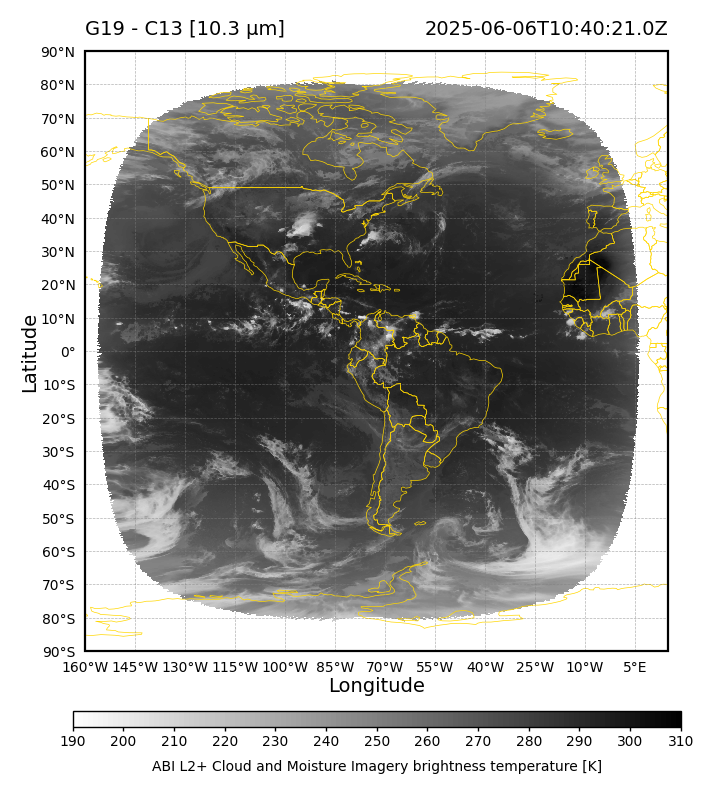

In [134]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

domain = [-160.0, 15.0, -90.0, 90.0] # Definimos el dominio de longitud y latitud
proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='110m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

# Reemplazamos Lons por LonCen.data, Lats por LatCen.data y tb por CMI.data
img = ax.contourf(LonCen.data, LatCen.data, CMI.data, transform=proj_sat, levels=np.arange(190, 311, 1), cmap='gray_r', vmin=190.0, vmax=310.0) # Graficamos el dato

# Configuración de la barra de colores
ticks = np.arange(190, 320, 10)
cb = plt.colorbar(img, ticks=ticks, orientation='horizontal', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - C{} [{:.1f} μm]'.format(sat, band_id, wl), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_contourf.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


## ¡Atención con la estructura del objeto generado por **open_dataset**!

In [135]:
ds

<class 'GOES.processing.processing_data.open_dataset'>

attribute:
   naming_authority              : gov.nesdis.noaa
   Conventions                   : CF-1.7
   Metadata_Conventions          : Unidata Dataset Discovery v1.0
   standard_name_vocabulary      : CF Standard Name Table (v35, 20 July 2016)
   institution                   : DOC/NOAA/NESDIS > U.S. Department of Commerce, N...
   project                       : GOES
   production_site               : RBU
   production_environment        : OE
   spatial_resolution            : 2km at nadir
   orbital_slot                  : GOES-East
   platform_ID                   : G19
   instrument_type               : GOES-R Series Advanced Baseline Imager (ABI)
   scene_id                      : Full Disk
   instrument_ID                 : FM4
   dataset_name                  : OR_ABI-L2-CMIPF-M6C13_G19_s20251571040210_e20251...
   iso_series_metadata_id        : 8c9e8150-3692-11e3-aa6e-0800200c9a66
   title                         : AB

El objeto generado por **open_dataset** presenta atributos (atributo, variable, image, group) y metodos.

Para acceder a un atributo utilicen el metodo **attribute()**:

In [136]:
ds.attribute('platform_ID')

'G19'

Para acceder a una variable utilicen el metodo **variable()**:

In [137]:
ds.variable('band_id')

<class 'GOES.processing.processing_data.GOES'>

Keys:
   long_name                     : ABI band number
   standard_name                 : sensor_band_identifier
   units                         : 1
   dimensions                    : (band)
   data                          (1) int32

In [139]:
ds.variable('band_id').data[:]

array([13], dtype=int32)

Para acceder a una imagen utilicen el metodo **image()**:

In [140]:
CMI, LonCen, LatCen = ds.image('CMI', lonlat='center')

In [141]:
print(CMI)

<class 'GOES.processing.processing_data.GOES'>

Keys:
   long_name                     : ABI L2+ Cloud and Moisture Imagery brightness te...
   standard_name                 : toa_brightness_temperature
   units                         : K
   undef                         : nan
   axis                          : YX
   dimensions                    : (y, x)
   t                             <class 'GOES.processing.processing_data.GOES'>
   time_bounds                   <class 'GOES.processing.processing_data.GOES'>
   pixels_limits                 (4) int64
   data                          (5424, 5424) float32



In [142]:
print(LonCen)

<class 'GOES.processing.processing_data.GOES'>

Keys:
   long_name                     : Longitude of center of pixels
   standard_name                 : pixels center longitude
   units                         : degrees_east
   undef                         : -999.99
   axis                          : YX
   dimensions                    : (y, x)
   data                          (5424, 5424) float32



In [143]:
print(LatCen)

<class 'GOES.processing.processing_data.GOES'>

Keys:
   long_name                     : Latitude of center of pixels
   standard_name                 : pixels center latitude
   units                         : degrees_north
   undef                         : -999.99
   axis                          : YX
   dimensions                    : (y, x)
   data                          (5424, 5424) float32



Para acceder a una imagen utilicen el metodo **group()**:

In [144]:
ds.group('HOLA')


	Parameter not found, check if it is a group



¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [145]:
del CMI, LonCen, LatCen, ds

<br>

# Graficando una imagen del ABI con **pcolormesh**

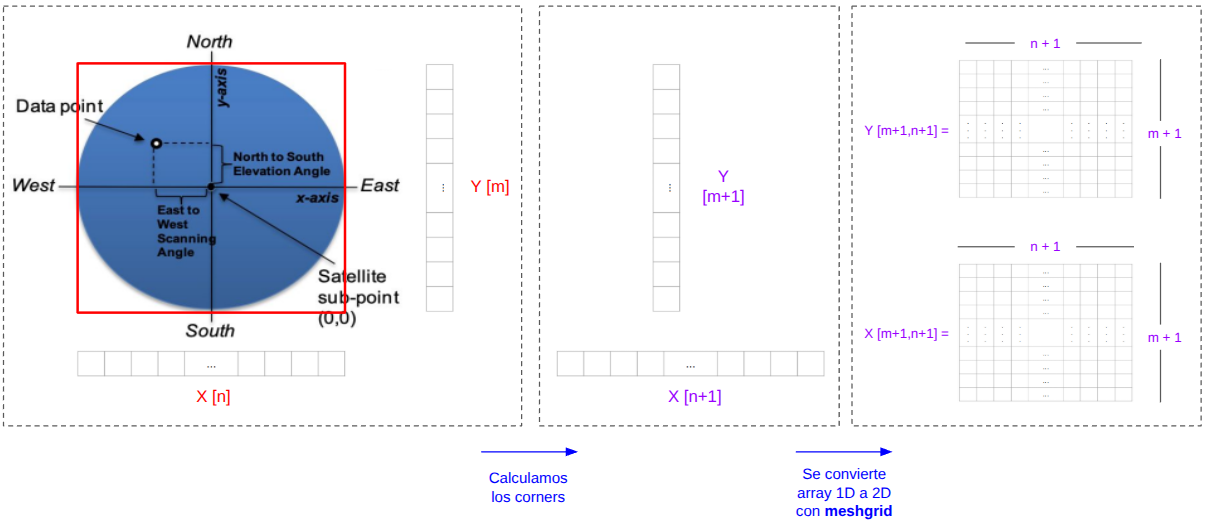

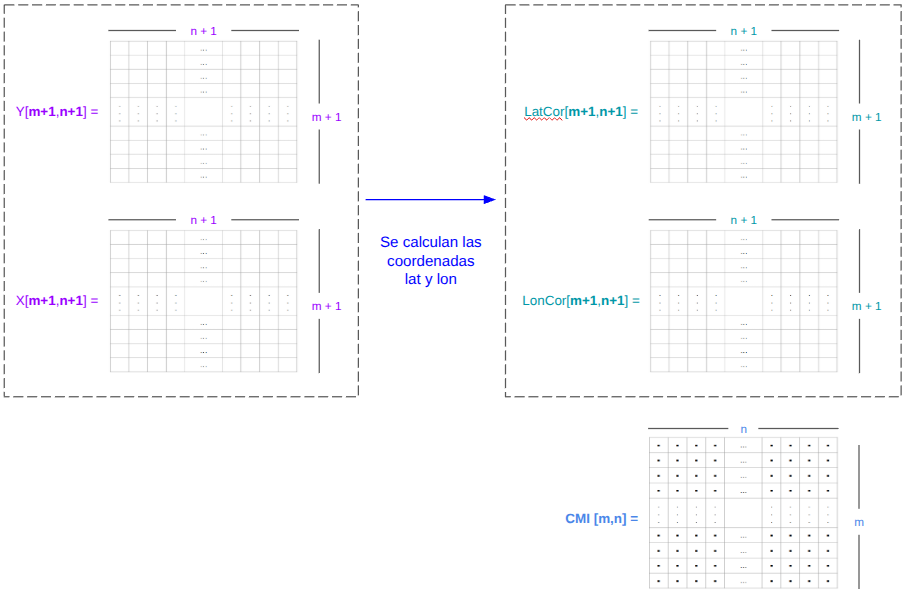

In [147]:
# Obteniendo el dato (imagen de satélite)

import GOES

ds = GOES.open_dataset(flist[2]) # Leemos el archivo nc

# Obtenemos el dato (imagen de satélite) y sus coordenadas (de las esquinas de cada elemento)
CMI, LonCor, LatCor = ds.image('CMI', lonlat='corner')

# Atributos del dato (imagen de satélite)
sat = ds.attribute('platform_ID')
time = ds.attribute('time_coverage_start')
band_id = ds.variable('band_id').data[0]
wl = ds.variable('band_wavelength').data[0]
long_name = CMI.long_name # Lo obtenemos de CMI
units = CMI.units # Lo obtenemos de CMI

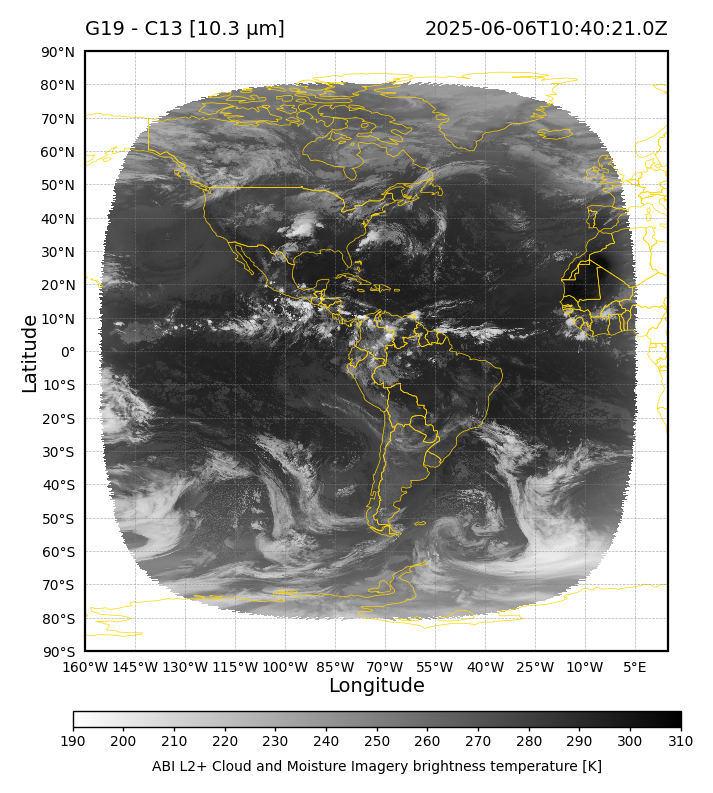

In [148]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

domain = [-160.0, 15.0, -90.0, 90.0] # Definimos el dominio de longitud y latitud
proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='110m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, CMI.data, transform=proj_sat, cmap='gray_r', vmin=190.0, vmax=310.0)

# Configuración de la barra de colores
ticks = np.arange(190, 320, 10)
cb = plt.colorbar(img, ticks=ticks, orientation='horizontal', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - C{} [{:.1f} μm]'.format(sat, band_id, wl), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_pcolormesh.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [149]:
del CMI, LonCor, LatCor, ds, img, fig

# Comparación entre imshow, contourf y pcolormesh

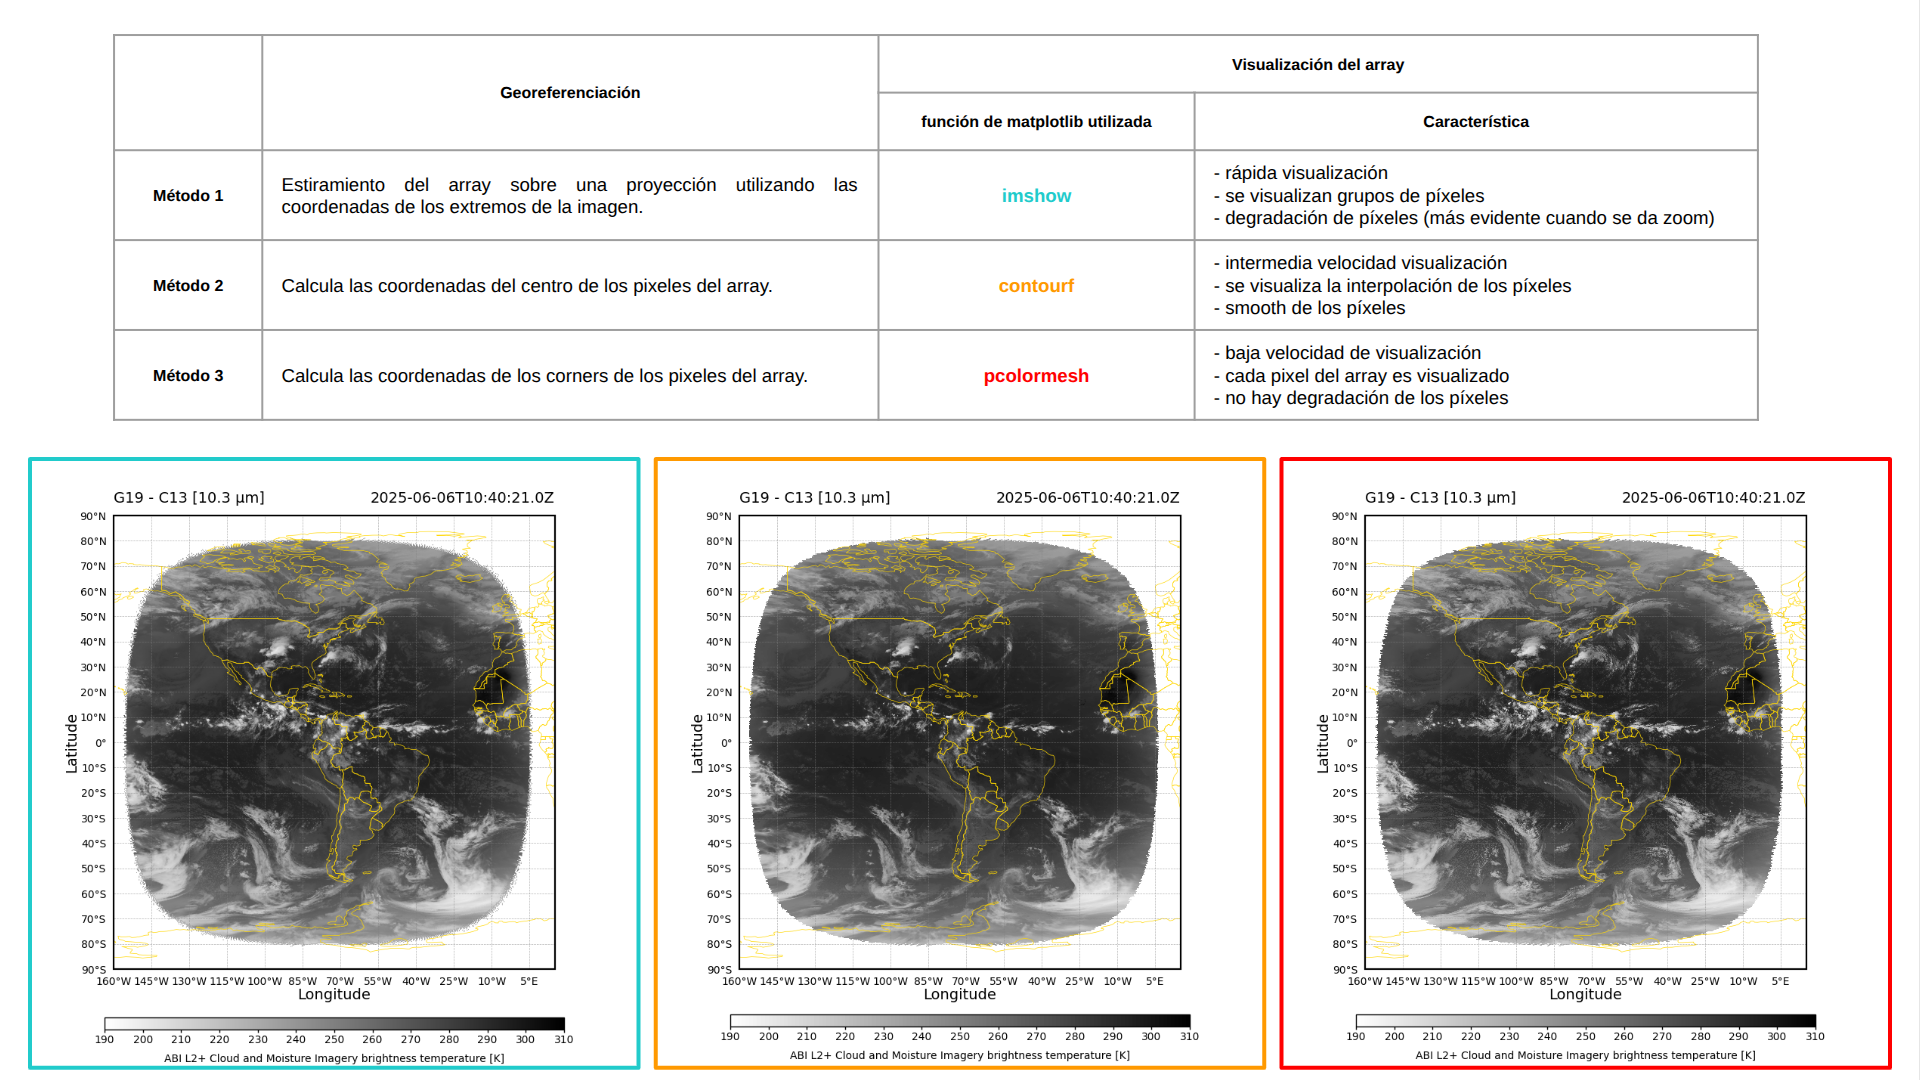